In [1]:
# MEA Case 1 — Plasma Reduced-Order Model Identification

## Objective

Determine whether a magnetically filtered plasma observable near a stable operating point is better represented by a first-order or second-order local reduced-order model.

The nominal operating point is

\[
B_\ast = 0.4~\mathrm{T}.
\]

Two candidate reduced observables are tested:

\[
q_{p,1}(t)=T_{e,\mathrm{cold}}(t)
\]

and

\[
q_{p,2}(t)=\frac{\delta n_e(t)}{n_0}.
\]

The governing scientific rule is:

> **Do not make the plasma a second-order oscillator unless the generated plasma-state data support that model.**

### Important scope statement

The transient equations used in this notebook constitute a **new simplified MEA plasma surrogate**.

They are not:
- prior PIC-MCC output;
- experimental data;
- a reproduction of the unpublished JMM2 simulation;
- or a replacement for kinetic plasma modelling.

The purpose is to construct a physically interpretable transient model suitable for ROM identification, model comparison, sensitivity testing, and design of the later higher-fidelity MEA experiment.

SyntaxError: invalid syntax (3406829072.py, line 5)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.signal import StateSpace, lsim
from scipy.integrate import solve_ivp

SEED = 20260819
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=5, suppress=True)

In [4]:
# ---------------------------------------------------------
# Published operating envelope
# ---------------------------------------------------------

BASELINE = {
    "B_star_T": 0.4,
    "Te_star_eV": 0.8,
    "rho_star": 0.10,          # baseline delta-ne / n0
    "rf_power_W": 100.0,
    "rf_frequency_Hz": 13.56e6,
}

# ---------------------------------------------------------
# Fresh MEA transient-surrogate assumptions
# ---------------------------------------------------------
#
# IMPORTANT:
# These coefficients are NEW modelling assumptions for MEA.
# They are not PIC-MCC-derived values.

SURROGATE = {
    "tau_T_s": 0.35e-6,
    "tau_n_s": 0.60e-6,

    # coupling coefficients
    "a": 0.75,        # density state -> electron-temperature state
    "b": 0.90,        # magnetic field -> cooling
    "c": 0.90,        # temperature state -> density state
    "d": 1.50,        # magnetic field -> density/confinement state

    # weak nonlinear saturation
    "gamma_T": 0.8,
    "gamma_n": 0.5,

    # stochastic diffusion amplitudes
    "sigma_T": 15.0,
    "sigma_n": 10.0,
}

SIM = {
    "dt_s": 5e-9,
    "t_end_s": 12e-6,
    "t_step_s": 2e-6,

    "n_realizations": 50,
    "n_train": 35,
}

# symmetric perturbations around B*=0.4 T
STEP_AMPLITUDES = np.array([
    -0.10,
    -0.05,
    -0.025,
     0.025,
     0.05,
     0.10
])

print(BASELINE)
print(SURROGATE)

{'B_star_T': 0.4, 'Te_star_eV': 0.8, 'rho_star': 0.1, 'rf_power_W': 100.0, 'rf_frequency_Hz': 13560000.0}
{'tau_T_s': 3.5e-07, 'tau_n_s': 6e-07, 'a': 0.75, 'b': 0.9, 'c': 0.9, 'd': 1.5, 'gamma_T': 0.8, 'gamma_n': 0.5, 'sigma_T': 15.0, 'sigma_n': 10.0}


In [5]:
## Fresh two-state plasma transient model

Define the normalized downstream electron-temperature deviation

\[
\theta(t)
=
\frac{
T_{e,\mathrm{cold}}(t)-T_{e,\ast}
}{
T_{e,\ast}
},
\]

and normalized electron-density perturbation state

\[
r(t)
=
\frac{
(\delta n_e/n_0)(t)-(\delta n_e/n_0)_\ast
}{
(\delta n_e/n_0)_\ast
}.
\]

The magnetic perturbation is

\[
u_B(t)
=
\frac{
B_\perp(t)-B_\ast
}{
B_\ast
}.
\]

The fresh MEA transient surrogate is

\[
\tau_T\dot{\theta}
=
-\theta
-a r
-bu_B
-\gamma_T\theta^3
+
\tau_T\sigma_T\xi_T(t),
\]

\[
\tau_n\dot r
=
-r
+c\theta
+du_B
-\gamma_n r^3
+
\tau_n\sigma_n\xi_n(t).
\]

Interpretation:

- increasing transverse magnetic field directly suppresses the energetic-electron state;
- magnetic confinement also modifies the downstream density state;
- temperature and density interact dynamically;
- the coupled first-order states may generate an effective second-order input-output response;
- weak cubic terms allow local linearity to fail at sufficiently large perturbations;
- stochastic terms represent unresolved collision and transport variability.

The model intentionally does **not** contain a mechanical mass.

SyntaxError: invalid syntax (3648467037.py, line 3)

In [6]:
tau_T = SURROGATE["tau_T_s"]
tau_n = SURROGATE["tau_n_s"]
a = SURROGATE["a"]
c = SURROGATE["c"]

A_local = np.array([
    [-1.0/tau_T, -a/tau_T],
    [ c/tau_n,   -1.0/tau_n]
])

eigvals = np.linalg.eigvals(A_local)

wn_local = np.sqrt(np.linalg.det(A_local))
zeta_local = -np.trace(A_local) / (2.0 * wn_local)

print("Linearized state matrix:")
print(A_local)

print("\nEigenvalues:")
print(eigvals)

print(
    "\nGenerator characteristic frequency:",
    wn_local/(2*np.pi),
    "Hz"
)

print(
    "Generator damping ratio:",
    zeta_local
)

Linearized state matrix:
[[-2857142.85714 -2142857.14286]
 [ 1500000.      -1666666.66667]]

Eigenvalues:
[-2261904.7619+1691146.74829j -2261904.7619-1691146.74829j]

Generator characteristic frequency: 449487.7807027581 Hz
Generator damping ratio: 0.8008967965656436


In [7]:
def simulate_plasma_step(step_amp, seed):
    """
    Fresh simplified MEA plasma transient surrogate.

    step_amp is Delta B / B_star.
    """

    local_rng = np.random.default_rng(seed)

    dt = SIM["dt_s"]

    t = np.arange(
        0.0,
        SIM["t_end_s"] + dt,
        dt
    )

    # state columns:
    # 0 = theta
    # 1 = r
    x = np.zeros((len(t), 2))

    p = SURROGATE
    sqrt_dt = np.sqrt(dt)

    for k in range(len(t) - 1):

        theta, r = x[k]

        if t[k] >= SIM["t_step_s"]:
            u = step_amp
        else:
            u = 0.0

        dtheta = (
            -theta
            - p["a"] * r
            - p["b"] * u
            - p["gamma_T"] * theta**3
        ) / p["tau_T_s"]

        dr = (
            -r
            + p["c"] * theta
            + p["d"] * u
            - p["gamma_n"] * r**3
        ) / p["tau_n_s"]

        x[k+1, 0] = (
            theta
            + dtheta * dt
            + p["sigma_T"]
            * sqrt_dt
            * local_rng.normal()
        )

        x[k+1, 1] = (
            r
            + dr * dt
            + p["sigma_n"]
            * sqrt_dt
            * local_rng.normal()
        )

    B = (
        BASELINE["B_star_T"]
        *
        (
            1.0
            +
            np.where(
                t >= SIM["t_step_s"],
                step_amp,
                0.0
            )
        )
    )

    Te = (
        BASELINE["Te_star_eV"]
        *
        (1.0 + x[:, 0])
    )

    density_ratio = (
        BASELINE["rho_star"]
        *
        (1.0 + x[:, 1])
    )

    return pd.DataFrame({
        "t_s": t,
        "B_T": B,
        "u_B": (
            B - BASELINE["B_star_T"]
        ) / BASELINE["B_star_T"],

        "theta": x[:, 0],
        "r": x[:, 1],

        "Te_cold_eV": Te,
        "delta_ne_over_n0": density_ratio
    })

In [8]:
ensembles = {}

for amp in STEP_AMPLITUDES:

    runs = []

    for j in range(
        SIM["n_realizations"]
    ):

        seed = (
            SEED
            + int(
                (amp + 0.2)
                * 1e6
            )
            + j
        )

        run = simulate_plasma_step(
            float(amp),
            seed
        )

        runs.append(run)

    ensembles[float(amp)] = runs

print(
    "Conditions generated:",
    sorted(ensembles.keys())
)

print(
    "Realizations per condition:",
    SIM["n_realizations"]
)

Conditions generated: [-0.1, -0.05, -0.025, 0.025, 0.05, 0.1]
Realizations per condition: 50


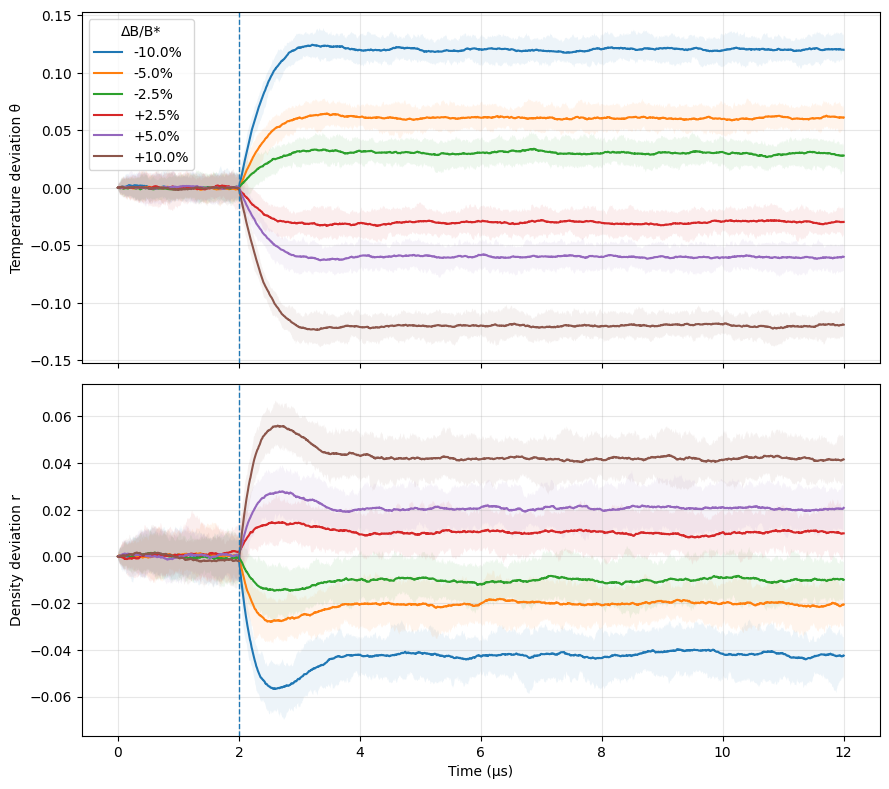

In [9]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True
)

for amp, runs in sorted(
    ensembles.items()
):

    t = (
        runs[0]["t_s"]
        .to_numpy()
        * 1e6
    )

    for ax, col in [
        (axes[0], "theta"),
        (axes[1], "r")
    ]:

        stack = np.stack([
            run[col].to_numpy()
            for run in runs
        ])

        mean = stack.mean(axis=0)

        lo = np.percentile(
            stack,
            2.5,
            axis=0
        )

        hi = np.percentile(
            stack,
            97.5,
            axis=0
        )

        ax.plot(
            t,
            mean,
            label=f"{amp:+.1%}"
        )

        ax.fill_between(
            t,
            lo,
            hi,
            alpha=0.08
        )

axes[0].set_ylabel(
    "Temperature deviation θ"
)

axes[1].set_ylabel(
    "Density deviation r"
)

axes[1].set_xlabel(
    "Time (µs)"
)

for ax in axes:

    ax.axvline(
        SIM["t_step_s"] * 1e6,
        linestyle="--",
        linewidth=1
    )

    ax.grid(alpha=0.3)

axes[0].legend(
    title="ΔB/B*"
)

plt.tight_layout()
plt.show()

In [10]:
def simulate_first_order(
    t,
    u,
    K,
    tau
):

    A = np.array([
        [-1.0/tau]
    ])

    B = np.array([
        [K/tau]
    ])

    C = np.array([
        [1.0]
    ])

    D = np.array([
        [0.0]
    ])

    sys = StateSpace(
        A,
        B,
        C,
        D
    )

    _, y, _ = lsim(
        sys,
        U=u,
        T=t
    )

    return (
        np.asarray(y)
        .reshape(-1)
    )


def simulate_second_order(
    t,
    u,
    K,
    wn,
    zeta
):

    A = np.array([
        [0.0, 1.0],
        [
            -wn**2,
            -2.0*zeta*wn
        ]
    ])

    B = np.array([
        [0.0],
        [K*wn**2]
    ])

    C = np.array([
        [1.0, 0.0]
    ])

    D = np.array([
        [0.0]
    ])

    sys = StateSpace(
        A,
        B,
        C,
        D
    )

    _, y, _ = lsim(
        sys,
        U=u,
        T=t
    )

    return (
        np.asarray(y)
        .reshape(-1)
    )

In [11]:
def nrmse(
    y_true,
    y_pred
):

    denom = np.std(y_true)

    if denom < 1e-12:

        denom = (
            np.ptp(y_true)
            + 1e-12
        )

    return (
        np.sqrt(
            np.mean(
                (
                    y_true
                    - y_pred
                )**2
            )
        )
        / denom
    )


def aicc(
    n,
    rss,
    k
):

    rss = max(
        float(rss),
        1e-30
    )

    aic = (
        n
        * np.log(
            rss / n
        )
        + 2*k
    )

    correction = (
        2*k*(k+1)
        /
        (n-k-1)
    )

    return (
        aic
        + correction
    )


def bic(
    n,
    rss,
    k
):

    rss = max(
        float(rss),
        1e-30
    )

    return (
        n
        * np.log(
            rss / n
        )
        +
        k
        * np.log(n)
    )

In [12]:
def prepare_condition(
    amp,
    output
):

    runs = ensembles[
        float(amp)
    ]

    n_train = SIM[
        "n_train"
    ]

    train = np.stack([
        run[output]
        .to_numpy()

        for run
        in runs[:n_train]
    ])

    test = np.stack([
        run[output]
        .to_numpy()

        for run
        in runs[n_train:]
    ])

    t_full = (
        runs[0]["t_s"]
        .to_numpy()
    )

    u_full = (
        runs[0]["u_B"]
        .to_numpy()
    )

    mask = (
        t_full
        >= SIM["t_step_s"]
    )

    t = (
        t_full[mask]
        -
        SIM["t_step_s"]
    )

    u = u_full[mask]

    y_train = (
        train[:, mask]
        .mean(axis=0)
    )

    y_test = (
        test[:, mask]
        .mean(axis=0)
    )

    # remove small stochastic
    # post-step offset

    y_train = (
        y_train
        - y_train[0]
    )

    y_test = (
        y_test
        - y_test[0]
    )

    return (
        t,
        u,
        y_train,
        y_test
    )

In [13]:
def fit_models(
    amp,
    output
):

    (
        t,
        u,
        y_train,
        y_test
    ) = prepare_condition(
        amp,
        output
    )

    # ----------------------------------
    # First-order model
    # ----------------------------------

    def residual_first(p):

        K = p[0]

        tau = np.exp(
            p[1]
        )

        pred = (
            simulate_first_order(
                t,
                u,
                K,
                tau
            )
        )

        return (
            pred
            - y_train
        )

    fit1 = least_squares(
        residual_first,
        [
            1.0,
            np.log(
                0.5e-6
            )
        ],
        max_nfev=300
    )

    K1 = fit1.x[0]

    tau1 = np.exp(
        fit1.x[1]
    )

    pred1 = (
        simulate_first_order(
            t,
            u,
            K1,
            tau1
        )
    )

    # ----------------------------------
    # Second-order model
    # ----------------------------------

    def residual_second(p):

        K = p[0]

        wn = np.exp(
            p[1]
        )

        zeta = np.exp(
            p[2]
        )

        pred = (
            simulate_second_order(
                t,
                u,
                K,
                wn,
                zeta
            )
        )

        return (
            pred
            - y_train
        )

    fit2 = least_squares(
        residual_second,
        [
            1.0,
            np.log(
                2.5e6
            ),
            np.log(
                0.8
            )
        ],
        max_nfev=500
    )

    K2 = fit2.x[0]

    wn2 = np.exp(
        fit2.x[1]
    )

    zeta2 = np.exp(
        fit2.x[2]
    )

    pred2 = (
        simulate_second_order(
            t,
            u,
            K2,
            wn2,
            zeta2
        )
    )

    # ----------------------------------
    # Metrics
    # ----------------------------------

    rss1 = np.sum(
        (
            y_train
            - pred1
        )**2
    )

    rss2 = np.sum(
        (
            y_train
            - pred2
        )**2
    )

    result = {

        "amp": amp,

        "output": output,

        "K1": K1,

        "tau1_s": tau1,

        "test_nrmse_1":
            nrmse(
                y_test,
                pred1
            ),

        "AICc_1":
            aicc(
                len(t),
                rss1,
                2
            ),

        "BIC_1":
            bic(
                len(t),
                rss1,
                2
            ),

        "K2": K2,

        "wn2_rad_s": wn2,

        "fn2_Hz":
            wn2
            /
            (2*np.pi),

        "zeta2": zeta2,

        "test_nrmse_2":
            nrmse(
                y_test,
                pred2
            ),

        "AICc_2":
            aicc(
                len(t),
                rss2,
                3
            ),

        "BIC_2":
            bic(
                len(t),
                rss2,
                3
            )
    }

    curves = (
        t,
        y_train,
        y_test,
        pred1,
        pred2
    )

    return (
        result,
        curves
    )

In [14]:
results = []
curves = {}

for output in [
    "theta",
    "r"
]:

    for amp in STEP_AMPLITUDES:

        (
            result,
            curve
        ) = fit_models(
            float(amp),
            output
        )

        results.append(
            result
        )

        curves[
            (
                output,
                float(amp)
            )
        ] = curve

fit_table = pd.DataFrame(
    results
)

fit_table

,amp,output,K1,tau1_s,test_nrmse_1,AICc_1,BIC_1,K2,wn2_rad_s,fn2_Hz,zeta2,test_nrmse_2,AICc_2,BIC_2
0,-0.100,theta,-1.193395,3.309371e-07,0.315855,-24016.132244,-24004.935445,-1.191373,7.006114e+06,1.115058e+06,1.152077,0.300988,-25079.289320,-25062.497131
1,-0.050,theta,-1.240235,3.295028e-07,0.246441,-25985.985980,-25974.789181,-1.238344,7.232124e+06,1.151028e+06,1.187814,0.233484,-26591.117623,-26574.325434
2,-0.025,theta,-1.164238,3.669417e-07,0.744966,-26593.917583,-26582.720784,-1.161867,6.027089e+06,9.592410e+05,1.100009,0.727496,-26798.745971,-26781.953782
3,0.025,theta,-1.200012,3.059374e-07,0.574108,-26455.425715,-26444.228916,-1.198469,7.561392e+06,1.203433e+06,1.162308,0.553964,-26620.290945,-26603.498756
4,0.050,theta,-1.210996,3.368339e-07,0.279251,-26773.368977,-26762.172179,-1.209414,7.862897e+06,1.251419e+06,1.319688,0.266499,-27295.998471,-27279.206282
5,0.100,theta,-1.197934,3.339528e-07,0.159771,-24088.747210,-24077.550411,-1.195882,6.848087e+06,1.089907e+06,1.138124,0.140783,-25210.478546,-25193.686357
6,-0.100,r,0.431210,9.864932e-08,0.942016,-22620.916615,-22609.719816,0.430522,9.108269e+06,1.449626e+06,0.497715,0.912773,-22865.565055,-22848.772866
7,-0.050,r,0.419982,8.786074e-08,0.842663,-24808.448382,-24797.251584,0.419309,9.377229e+06,1.492432e+06,0.468684,0.801946,-24962.541286,-24945.749097
8,-0.025,r,0.426279,1.049454e-07,1.244752,-26708.727571,-26697.530772,0.425250,7.647797e+06,1.217185e+06,0.430583,1.237085,-26959.319508,-26942.527319
9,0.025,r,0.354718,8.896072e-08,0.960189,-26155.466079,-26144.269280,0.353956,8.154996e+06,1.297908e+06,0.403788,0.964244,-26294.385104,-26277.592915


In [ ]:
## Second-order acceptance criteria

A candidate observable supports the MEA second-order ROM only if the following conditions are satisfied.

### 1. Held-out prediction

The median second-order NRMSE must improve by at least 15% relative to the first-order model.

### 2. Information criterion

\[
\Delta\mathrm{AICc}
=
\mathrm{AICc}_1
-
\mathrm{AICc}_2
\ge 10.
\]

### 3. Natural-frequency stability

Across

\[
\Delta B/B_\ast
=
\pm2.5\%,
\pm5\%,
\pm10\%,
\]

the coefficient of variation of the identified natural frequency must satisfy

\[
CV(\omega_n)<0.15.
\]

### 4. Damping stability

\[
CV(\zeta)<0.20.
\]

### 5. Sign symmetry

Positive and negative field perturbations should not produce materially different fitted dynamic parameters.

If these conditions fail, the second-order interpretation is not accepted.

In [15]:
CRITERIA = {

    "min_improvement":
        0.15,

    "min_delta_aicc":
        10.0,

    "max_cv_wn":
        0.15,

    "max_cv_zeta":
        0.20
}


def summarize_candidate(
    output
):

    d = fit_table[
        fit_table["output"]
        == output
    ].copy()

    improvement = (
        1.0
        -
        d["test_nrmse_2"]
        /
        d["test_nrmse_1"]
    )

    delta_aicc = (
        d["AICc_1"]
        -
        d["AICc_2"]
    )

    cv_wn = (
        d["wn2_rad_s"].std()
        /
        d["wn2_rad_s"].mean()
    )

    cv_zeta = (
        d["zeta2"].std()
        /
        d["zeta2"].mean()
    )

    summary = {

        "median_holdout_improvement":
            float(
                np.median(
                    improvement
                )
            ),

        "median_delta_AICc":
            float(
                np.median(
                    delta_aicc
                )
            ),

        "cv_wn":
            float(cv_wn),

        "cv_zeta":
            float(cv_zeta)
    }

    accepted = (

        summary[
            "median_holdout_improvement"
        ]
        >=
        CRITERIA[
            "min_improvement"
        ]

        and

        summary[
            "median_delta_AICc"
        ]
        >=
        CRITERIA[
            "min_delta_aicc"
        ]

        and

        summary["cv_wn"]
        <=
        CRITERIA[
            "max_cv_wn"
        ]

        and

        summary["cv_zeta"]
        <=
        CRITERIA[
            "max_cv_zeta"
        ]
    )

    return (
        summary,
        accepted
    )


for output in [
    "theta",
    "r"
]:

    summary, accepted = (
        summarize_candidate(
            output
        )
    )

    print(
        "\nOUTPUT:",
        output
    )

    print(
        summary
    )

    print(
        "SECOND ORDER ACCEPTED:",
        accepted
    )


OUTPUT: theta
{'median_holdout_improvement': 0.046366077415237905, 'median_delta_AICc': 563.8805685366806, 'cv_wn': 0.08998850079994807, 'cv_zeta': 0.06444580516998852}
SECOND ORDER ACCEPTED: False

OUTPUT: r
{'median_holdout_improvement': 0.02994610791876079, 'median_delta_AICc': 242.7218301675657, 'cv_wn': 0.07791878215911921, 'cv_zeta': 0.09825989195138904}
SECOND ORDER ACCEPTED: False


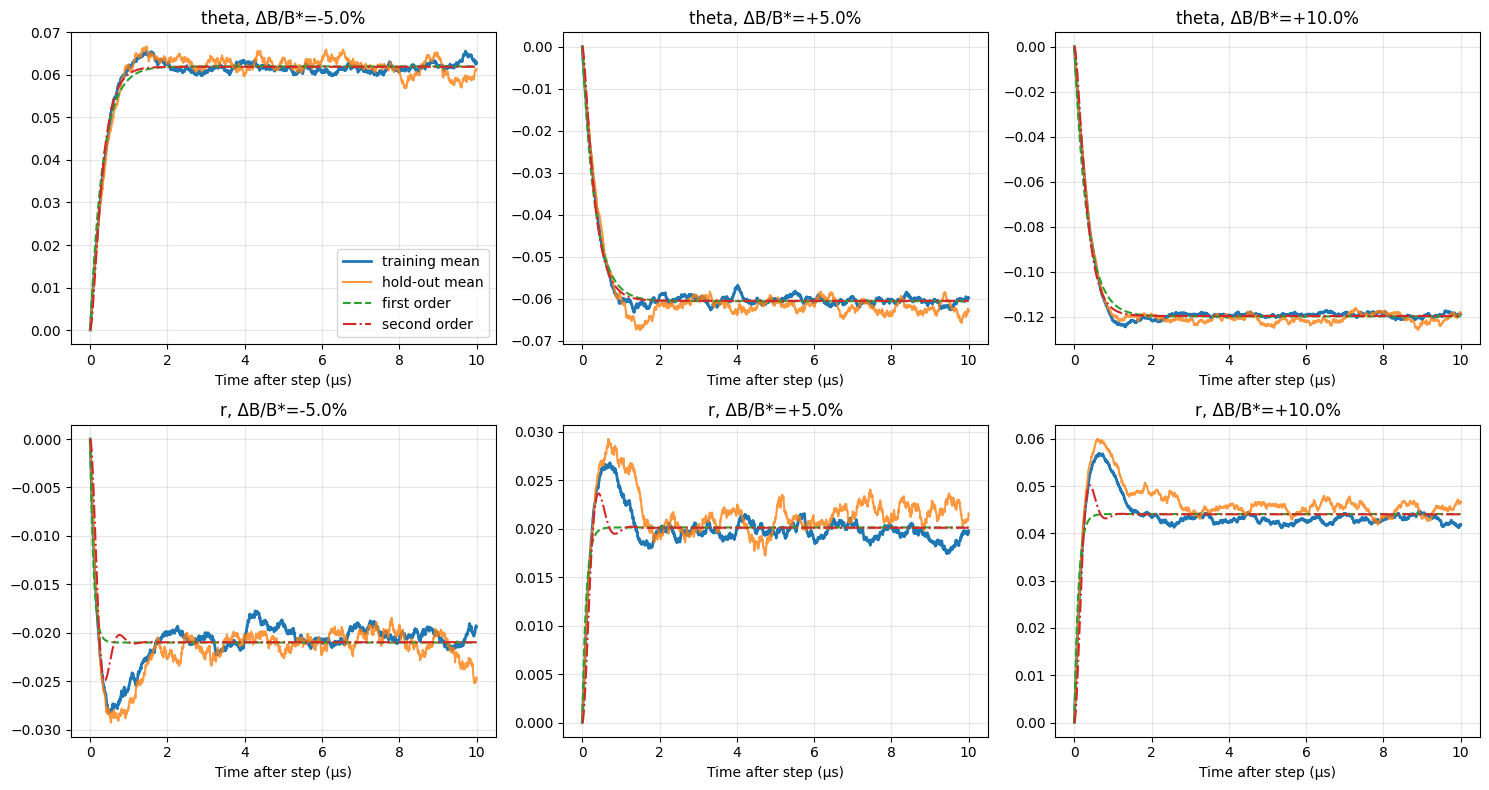

In [16]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

selected_amplitudes = [
    -0.05,
     0.05,
     0.10
]

for row, output in enumerate([
    "theta",
    "r"
]):

    for col, amp in enumerate(
        selected_amplitudes
    ):

        (
            t,
            y_train,
            y_test,
            pred1,
            pred2
        ) = curves[
            (
                output,
                amp
            )
        ]

        ax = axes[
            row,
            col
        ]

        ax.plot(
            t * 1e6,
            y_train,
            label="training mean",
            linewidth=2
        )

        ax.plot(
            t * 1e6,
            y_test,
            label="hold-out mean",
            alpha=0.8
        )

        ax.plot(
            t * 1e6,
            pred1,
            "--",
            label="first order"
        )

        ax.plot(
            t * 1e6,
            pred2,
            "-.",
            label="second order"
        )

        ax.set_title(
            f"{output}, "
            f"ΔB/B*={amp:+.1%}"
        )

        ax.set_xlabel(
            "Time after step (µs)"
        )

        ax.grid(
            alpha=0.3
        )

axes[0, 0].legend()

plt.tight_layout()
plt.show()

In [19]:
## Frequency-response test

After the step-response model-selection experiment, apply a small sinusoidal field modulation:

\[
B_\perp(t)
=
B_\ast
\left[
1+
0.05\sin(\omega t)
\right].
\]

The purpose is to determine whether the candidate plasma observable exhibits:

- a finite resonance peak;
- phase roll-off;
- underdamped dynamics;

or instead behaves primarily as a first-order low-pass process.

SyntaxError: invalid syntax (3972930014.py, line 3)

In [17]:
def rhs_sinusoidal(
    t,
    x,
    input_amp,
    omega
):

    theta, r = x

    p = SURROGATE

    u = (
        input_amp
        * np.sin(
            omega * t
        )
    )

    dtheta = (
        -theta
        - p["a"]*r
        - p["b"]*u
        - p["gamma_T"]*theta**3
    ) / p["tau_T_s"]

    dr = (
        -r
        + p["c"]*theta
        + p["d"]*u
        - p["gamma_n"]*r**3
    ) / p["tau_n_s"]

    return [
        dtheta,
        dr
    ]


def estimate_sine_response(
    t,
    y,
    omega
):

    X = np.column_stack([
        np.sin(
            omega*t
        ),
        np.cos(
            omega*t
        ),
        np.ones_like(t)
    ])

    beta = (
        np.linalg.lstsq(
            X,
            y,
            rcond=None
        )[0]
    )

    sin_coeff = beta[0]
    cos_coeff = beta[1]

    amplitude = (
        np.hypot(
            sin_coeff,
            cos_coeff
        )
    )

    phase = (
        np.arctan2(
            cos_coeff,
            sin_coeff
        )
    )

    return (
        amplitude,
        phase
    )

In [18]:
def frequency_point(
    freq_Hz,
    output_index,
    input_amp=0.05,
    total_cycles=30,
    discard_cycles=15
):

    omega = (
        2*np.pi*freq_Hz
    )

    period = (
        1.0/freq_Hz
    )

    t_end = (
        total_cycles
        * period
    )

    sol = solve_ivp(

        rhs_sinusoidal,

        (
            0,
            t_end
        ),

        [
            0.0,
            0.0
        ],

        args=(
            input_amp,
            omega
        ),

        max_step=(
            period/100
        ),

        rtol=1e-7,
        atol=1e-9
    )

    keep = (
        sol.t
        >=
        discard_cycles
        * period
    )

    amp, phase = (
        estimate_sine_response(

            sol.t[keep],

            sol.y[
                output_index,
                keep
            ],

            omega
        )
    )

    gain = (
        amp
        /
        input_amp
    )

    return (
        gain,
        phase
    )


frequencies = np.logspace(
    np.log10(5e4),
    np.log10(2e6),
    32
)

frf_rows = []

for output, index in [
    ("theta", 0),
    ("r", 1)
]:

    for f in frequencies:

        gain, phase = (
            frequency_point(
                float(f),
                index
            )
        )

        frf_rows.append({

            "output":
                output,

            "freq_Hz":
                f,

            "gain":
                gain,

            "phase_rad":
                phase
        })


frf = pd.DataFrame(
    frf_rows
)

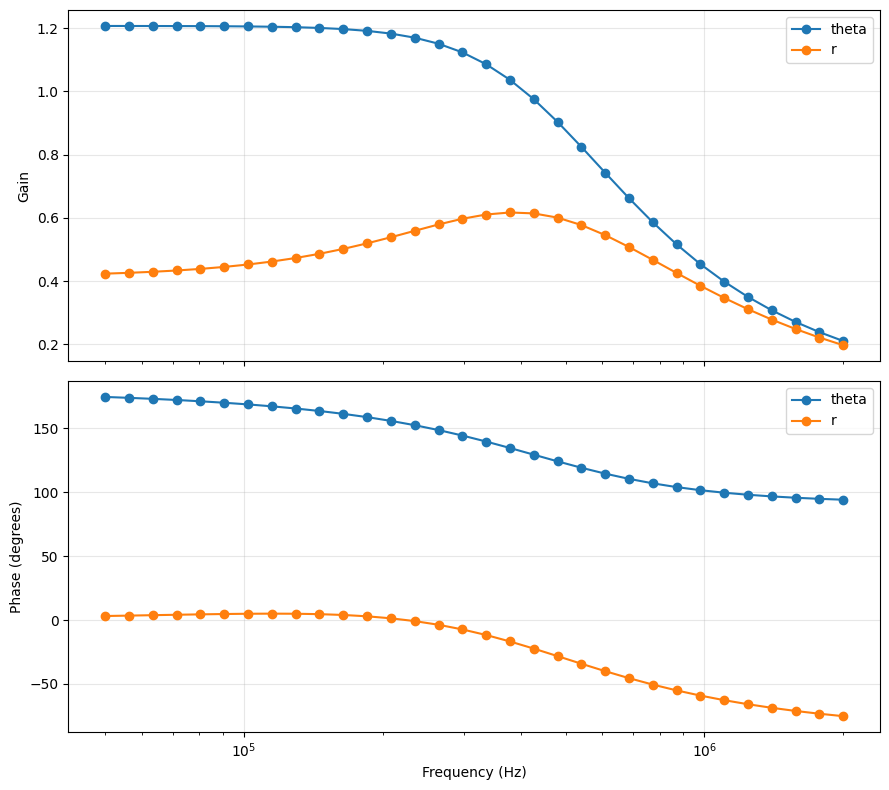

In [19]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True
)

for output in [
    "theta",
    "r"
]:

    d = frf[
        frf["output"]
        == output
    ]

    axes[0].semilogx(
        d["freq_Hz"],
        d["gain"],
        marker="o",
        label=output
    )

    axes[1].semilogx(
        d["freq_Hz"],
        np.unwrap(
            d["phase_rad"]
        )
        * 180
        / np.pi,
        marker="o",
        label=output
    )

axes[0].set_ylabel(
    "Gain"
)

axes[1].set_ylabel(
    "Phase (degrees)"
)

axes[1].set_xlabel(
    "Frequency (Hz)"
)

for ax in axes:

    ax.grid(
        alpha=0.3
    )

    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
## Dimensionless quantities for later cross-domain comparison

If a second-order plasma ROM is accepted, define

\[
\Omega_p
=
\frac{\omega}
{\omega_{n,p}},
\]

and use the fitted damping ratio

\[
\zeta_p.
\]

A physically motivated magnetic-coupling parameter is

\[
\Pi_{C,p}
=
\frac{\omega_{ce}}
{\nu_{en}},
\]

where

\[
\omega_{ce}
=
\frac{eB_\perp}{m_e}.
\]

This compares magnetic gyromotion with collisional relaxation.

A separate forcing/control parameter is

\[
\Pi_{F,p}
=
\frac{P_{\mathrm{RF}}}
{P_{\mathrm{RF},\ast}}.
\]

The collision frequency \(\nu_{en}\) must later be calculated from a defensible gas-pressure, cross-section, and electron-energy model. It must not be arbitrarily inserted.

SyntaxError: invalid syntax (135811742.py, line 3)

In [20]:
import json
from pathlib import Path

OUT = Path(
    "mea_case1_outputs"
)

OUT.mkdir(
    exist_ok=True
)

fit_table.to_csv(
    OUT
    /
    "case1_model_fits.csv",
    index=False
)

frf.to_csv(
    OUT
    /
    "case1_frequency_response.csv",
    index=False
)

summary = {}

for output in [
    "theta",
    "r"
]:

    checks, accepted = (
        summarize_candidate(
            output
        )
    )

    summary[output] = {

        "checks":
            checks,

        "second_order_accepted":
            accepted
    }


with open(
    OUT
    /
    "case1_candidate_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


configuration = {

    "seed":
        SEED,

    "baseline":
        BASELINE,

    "surrogate":
        SURROGATE,

    "simulation":
        SIM,

    "step_amplitudes":
        STEP_AMPLITUDES.tolist(),

    "criteria":
        CRITERIA,

    "warning":
        (
            "Fresh simplified MEA transient surrogate. "
            "Not PIC-MCC-derived or experimental data."
        )
}


with open(
    OUT
    /
    "case1_configuration.json",
    "w"
) as f:

    json.dump(
        configuration,
        f,
        indent=2
    )


print(
    "Outputs written to:",
    OUT.resolve()
)

Outputs written to: /content/mea_case1_outputs


In [ ]:
# Case 1B — Coupled Linear State-Space Identification

Case 1A tested the two plasma observables independently using scalar first- and second-order transfer functions.

The second-order acceptance criterion was not satisfied for either observable, although the fitted parameters were relatively stable and the density response exhibited underdamped structure.

Case 1B therefore tests the more general coupled model

\[
\dot{\mathbf{x}}
=
\mathbf{A}_p\mathbf{x}
+
\mathbf{B}_p u_B
+
\mathbf{w}(t),
\]

where

\[
\mathbf{x}
=
\begin{bmatrix}
\theta\\
r
\end{bmatrix}.
\]

The objectives are to determine:

1. whether a single \(2\times2\) state matrix describes all small magnetic perturbations;
2. whether its eigenvalues are stable across perturbation magnitude and sign;
3. whether the model predicts held-out trajectories;
4. whether a complex-conjugate modal pair emerges naturally;
5. whether meaningful modal quantities \(\omega_n\) and \(\zeta\) can be obtained without introducing a fictitious plasma mass.

The identification model is linear and local. The nonlinear stochastic surrogate remains the data generator.

In [21]:
## State-space interpretation

For a two-state model

\[
\dot{\mathbf{x}}
=
\mathbf{A}\mathbf{x}
+
\mathbf{B}u,
\]

the system matrix may be written

\[
\mathbf{A}
=
\begin{bmatrix}
a_{11} & a_{12}\\
a_{21} & a_{22}
\end{bmatrix}.
\]

The characteristic equation is

\[
\lambda^2
-
\operatorname{tr}(\mathbf{A})\lambda
+
\det(\mathbf{A})
=
0.
\]

If the eigenvalues are

\[
\lambda_{1,2}
=
-\sigma
\pm j\omega_d,
\]

then the equivalent modal quantities are

\[
\omega_n
=
\sqrt{\sigma^2+\omega_d^2}
=
\sqrt{\det(\mathbf{A})},
\]

and

\[
\zeta
=
\frac{\sigma}{\omega_n}
=
-\frac{\operatorname{tr}(\mathbf{A})}
{2\sqrt{\det(\mathbf{A})}}.
\]

These quantities describe the eigenmode of the reduced plasma dynamics. They do not imply mechanical inertia or literal spring stiffness.

SyntaxError: invalid syntax (2851147946.py, line 3)

In [22]:
from scipy.signal import savgol_filter

def smooth_and_differentiate(
    t,
    x,
    window_length=101,
    polyorder=3
):
    """
    Smooth state trajectory and estimate dx/dt.

    x shape: (N, n_states)
    """

    dt = np.mean(np.diff(t))

    # window must be odd
    if window_length % 2 == 0:
        window_length += 1

    if window_length >= len(t):
        window_length = len(t) - 1

        if window_length % 2 == 0:
            window_length -= 1

    xs = np.zeros_like(x)
    dx = np.zeros_like(x)

    for j in range(
        x.shape[1]
    ):

        xs[:, j] = savgol_filter(
            x[:, j],
            window_length=window_length,
            polyorder=polyorder
        )

        dx[:, j] = savgol_filter(
            x[:, j],
            window_length=window_length,
            polyorder=polyorder,
            deriv=1,
            delta=dt
        )

    return xs, dx

In [23]:
def prepare_state_condition(
    amp,
    subset="train"
):

    runs = ensembles[
        float(amp)
    ]

    if subset == "train":

        selected = runs[
            :SIM["n_train"]
        ]

    elif subset == "test":

        selected = runs[
            SIM["n_train"]:
        ]

    else:

        raise ValueError(
            "subset must be "
            "'train' or 'test'"
        )

    t_full = (
        selected[0]["t_s"]
        .to_numpy()
    )

    mask = (
        t_full
        >= SIM["t_step_s"]
    )

    t = (
        t_full[mask]
        -
        SIM["t_step_s"]
    )

    theta = np.stack([
        run["theta"]
        .to_numpy()[mask]

        for run
        in selected
    ]).mean(axis=0)

    r = np.stack([
        run["r"]
        .to_numpy()[mask]

        for run
        in selected
    ]).mean(axis=0)

    u = (
        selected[0]["u_B"]
        .to_numpy()[mask]
    )

    # remove tiny stochastic
    # offset at t = 0

    theta = theta - theta[0]
    r = r - r[0]

    x = np.column_stack([
        theta,
        r
    ])

    return (
        t,
        x,
        u
    )

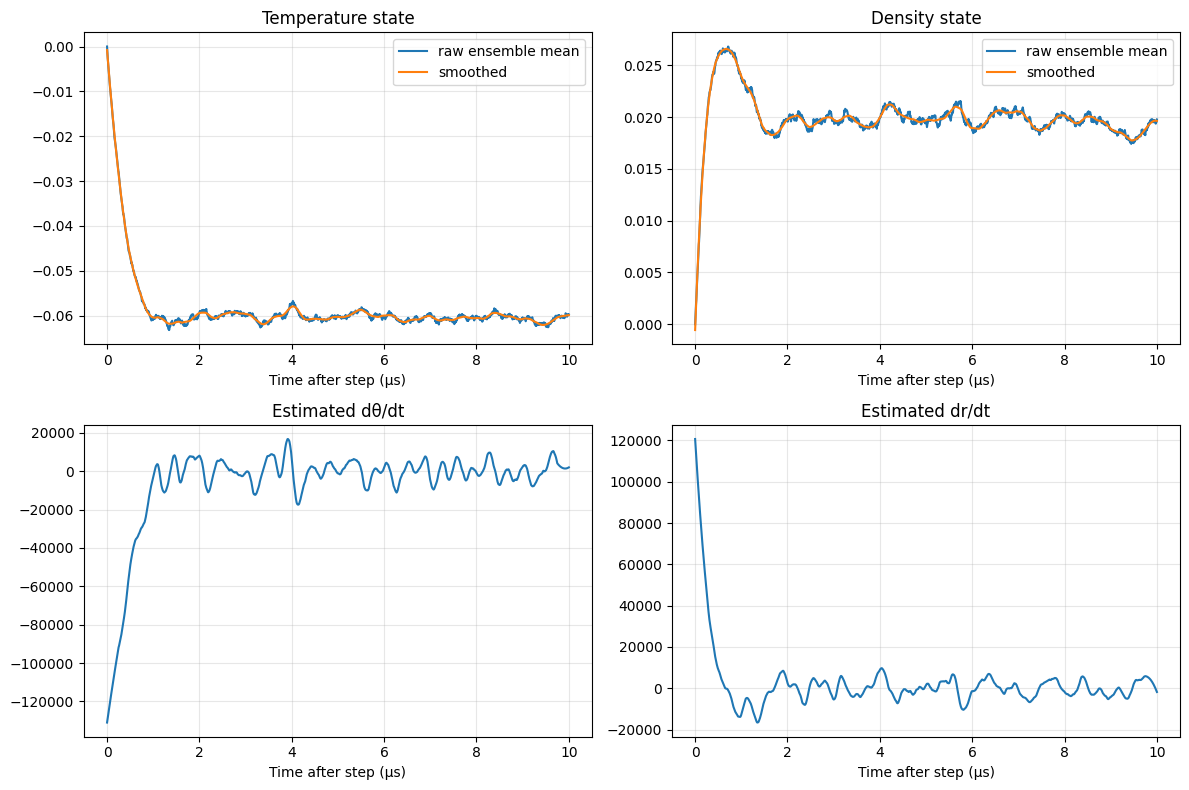

In [24]:
amp_demo = 0.05

t_demo, x_demo, u_demo = (
    prepare_state_condition(
        amp_demo,
        "train"
    )
)

xs_demo, dx_demo = (
    smooth_and_differentiate(
        t_demo,
        x_demo,
        window_length=101,
        polyorder=3
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes[0,0].plot(
    t_demo*1e6,
    x_demo[:,0],
    label="raw ensemble mean"
)

axes[0,0].plot(
    t_demo*1e6,
    xs_demo[:,0],
    label="smoothed"
)

axes[0,0].set_title(
    "Temperature state"
)

axes[0,1].plot(
    t_demo*1e6,
    x_demo[:,1],
    label="raw ensemble mean"
)

axes[0,1].plot(
    t_demo*1e6,
    xs_demo[:,1],
    label="smoothed"
)

axes[0,1].set_title(
    "Density state"
)

axes[1,0].plot(
    t_demo*1e6,
    dx_demo[:,0]
)

axes[1,0].set_title(
    "Estimated dθ/dt"
)

axes[1,1].plot(
    t_demo*1e6,
    dx_demo[:,1]
)

axes[1,1].set_title(
    "Estimated dr/dt"
)

for ax in axes.flat:

    ax.set_xlabel(
        "Time after step (µs)"
    )

    ax.grid(
        alpha=0.3
    )

axes[0,0].legend()
axes[0,1].legend()

plt.tight_layout()
plt.show()

In [25]:
# Rebuild Case 1A ensembles for Case 1B

ensembles = {}

for amp in STEP_AMPLITUDES:

    runs = []

    for j in range(SIM["n_realizations"]):

        seed = (
            SEED
            + int((amp + 0.2) * 1e6)
            + j
        )

        runs.append(
            simulate_plasma_step(
                float(amp),
                seed
            )
        )

    ensembles[float(amp)] = runs


print(
    "Rebuilt conditions:",
    sorted(ensembles.keys())
)

print(
    "Realizations per condition:",
    len(ensembles[0.05])
)

Rebuilt conditions: [-0.1, -0.05, -0.025, 0.025, 0.05, 0.1]
Realizations per condition: 50


In [26]:
# Case 1B prerequisite guard

required_names = [
    "SEED",
    "BASELINE",
    "SURROGATE",
    "SIM",
    "STEP_AMPLITUDES",
    "simulate_plasma_step",
    "ensembles"
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Case 1B prerequisites missing: "
        + ", ".join(missing)
        + ". Re-run the Case 1A setup and ensemble-generation cells."
    )

print("Case 1B prerequisites: OK")

Case 1B prerequisites: OK


In [27]:
def identify_state_space(
    t,
    x,
    u,
    window_length=101,
    polyorder=3
):

    xs, dx = (
        smooth_and_differentiate(
            t,
            x,
            window_length,
            polyorder
        )
    )

    Z = np.column_stack([
        xs,
        u
    ])

    # Solve:
    # Z @ M ≈ dx

    M, residuals, rank, svals = (
        np.linalg.lstsq(
            Z,
            dx,
            rcond=None
        )
    )

    A = M[:2, :].T

    B = (
        M[2, :]
        .reshape(2, 1)
    )

    dx_pred = (
        Z @ M
    )

    return {

        "A":
            A,

        "B":
            B,

        "x_smooth":
            xs,

        "dx":
            dx,

        "dx_pred":
            dx_pred,

        "rank":
            rank,

        "singular_values":
            svals
    }

In [28]:
id_demo = (
    identify_state_space(
        t_demo,
        x_demo,
        u_demo
    )
)

print(
    "Identified A:"
)

print(
    id_demo["A"]
)

print(
    "\nIdentified B:"
)

print(
    id_demo["B"]
)

print(
    "\nEigenvalues:"
)

print(
    np.linalg.eigvals(
        id_demo["A"]
    )
)

Identified A:
[[-2846544.81406 -1986111.73425]
 [ 1497914.41015 -1658769.24829]]

Identified B:
[[-2656006.81339]
 [ 2452330.64437]]

Eigenvalues:
[-2252657.03118+1619358.72747j -2252657.03118-1619358.72747j]


In [29]:
def modal_properties(A):

    eigvals = (
        np.linalg.eigvals(A)
    )

    trace_A = (
        np.trace(A)
    )

    det_A = (
        np.linalg.det(A)
    )

    result = {

        "eig1":
            eigvals[0],

        "eig2":
            eigvals[1],

        "trace":
            trace_A,

        "det":
            det_A,

        "stable":
            bool(
                np.all(
                    np.real(
                        eigvals
                    )
                    < 0
                )
            ),

        "complex_pair":
            bool(
                np.any(
                    np.abs(
                        np.imag(
                            eigvals
                        )
                    )
                    > 1e-9
                )
            )
    }

    if det_A > 0:

        wn = np.sqrt(
            det_A
        )

        zeta = (
            -trace_A
            /
            (2*wn)
        )

        result[
            "wn_rad_s"
        ] = wn

        result[
            "fn_Hz"
        ] = (
            wn
            /
            (2*np.pi)
        )

        result[
            "zeta"
        ] = zeta

    else:

        result[
            "wn_rad_s"
        ] = np.nan

        result[
            "fn_Hz"
        ] = np.nan

        result[
            "zeta"
        ] = np.nan

    return result

In [30]:
modal_demo = (
    modal_properties(
        id_demo["A"]
    )
)

modal_demo

{'eig1': np.complex128(-2252657.0311782053+1619358.7274746464j),
 'eig2': np.complex128(-2252657.0311782053-1619358.7274746464j),
 'trace': np.float64(-4505314.0623564115),
 'det': np.float64(7696786388364.933),
 'stable': True,
 'complex_pair': True,
 'wn_rad_s': np.float64(2774308.2720499774),
 'fn_Hz': np.float64(441544.8751574887),
 'zeta': np.float64(0.8119707005428363)}

In [31]:
def simulate_identified_state_space(
    t,
    u,
    A,
    B,
    x0=None
):

    if x0 is None:

        x0 = np.zeros(2)

    C = np.eye(2)

    D = np.zeros(
        (2,1)
    )

    system = StateSpace(
        A,
        B,
        C,
        D
    )

    tout, y, xout = lsim(
        system,
        U=u,
        T=t,
        X0=x0
    )

    return (
        tout,
        np.asarray(y)
    )

In [32]:
def evaluate_state_space_condition(
    amp,
    window_length=101
):

    (
        t_train,
        x_train,
        u_train
    ) = prepare_state_condition(
        amp,
        "train"
    )

    (
        t_test,
        x_test,
        u_test
    ) = prepare_state_condition(
        amp,
        "test"
    )

    identified = (
        identify_state_space(
            t_train,
            x_train,
            u_train,
            window_length=window_length
        )
    )

    A = identified["A"]
    B = identified["B"]

    _, pred_train = (
        simulate_identified_state_space(
            t_train,
            u_train,
            A,
            B,
            x0=x_train[0]
        )
    )

    _, pred_test = (
        simulate_identified_state_space(
            t_test,
            u_test,
            A,
            B,
            x0=x_test[0]
        )
    )

    train_rmse = np.sqrt(
        np.mean(
            (
                x_train
                - pred_train
            )**2,
            axis=0
        )
    )

    test_rmse = np.sqrt(
        np.mean(
            (
                x_test
                - pred_test
            )**2,
            axis=0
        )
    )

    # normalized independently
    # for each state

    scale = np.std(
        x_test,
        axis=0
    )

    scale[
        scale < 1e-12
    ] = 1.0

    test_nrmse = (
        test_rmse
        /
        scale
    )

    modal = (
        modal_properties(A)
    )

    return {

        "amp":
            amp,

        "A":
            A,

        "B":
            B,

        "modal":
            modal,

        "train_rmse":
            train_rmse,

        "test_rmse":
            test_rmse,

        "test_nrmse":
            test_nrmse,

        "t_test":
            t_test,

        "x_test":
            x_test,

        "pred_test":
            pred_test
    }

In [34]:
case1b_results = []

for amp in STEP_AMPLITUDES:

    result = (
        evaluate_state_space_condition(
            float(amp)
        )
    )

    case1b_results.append(
        result
    )

print(
    "Case 1B conditions complete:",
    len(
        case1b_results
    )
)

Case 1B conditions complete: 6


In [35]:
case1b_rows = []

for res in case1b_results:

    A = res["A"]
    B = res["B"]
    m = res["modal"]

    case1b_rows.append({

        "amp":
            res["amp"],

        "A11":
            A[0,0],

        "A12":
            A[0,1],

        "A21":
            A[1,0],

        "A22":
            A[1,1],

        "B1":
            B[0,0],

        "B2":
            B[1,0],

        "eig1_real":
            np.real(
                m["eig1"]
            ),

        "eig1_imag":
            np.imag(
                m["eig1"]
            ),

        "eig2_real":
            np.real(
                m["eig2"]
            ),

        "eig2_imag":
            np.imag(
                m["eig2"]
            ),

        "stable":
            m["stable"],

        "complex_pair":
            m[
                "complex_pair"
            ],

        "wn_rad_s":
            m[
                "wn_rad_s"
            ],

        "fn_Hz":
            m[
                "fn_Hz"
            ],

        "zeta":
            m[
                "zeta"
            ],

        "test_nrmse_theta":
            res[
                "test_nrmse"
            ][0],

        "test_nrmse_r":
            res[
                "test_nrmse"
            ][1]
    })


case1b_table = (
    pd.DataFrame(
        case1b_rows
    )
)

case1b_table

,amp,A11,A12,A21,A22,B1,B2,eig1_real,eig1_imag,eig2_real,eig2_imag,stable,complex_pair,wn_rad_s,fn_Hz,zeta,test_nrmse_theta,test_nrmse_r
0,-0.100,-2.964025e+06,-2.181865e+06,1.573038e+06,-1.684833e+06,-2.605655e+06,2.574930e+06,-2.324429e+06,1.738698e+06,-2.324429e+06,-1.738698e+06,True,True,2.902765e+06,461989.378749,0.800764,0.283315,0.578833
1,-0.050,-2.853924e+06,-2.037770e+06,1.594575e+06,-1.707575e+06,-2.696903e+06,2.660910e+06,-2.280749e+06,1.709049e+06,-2.280749e+06,-1.709049e+06,True,True,2.850029e+06,453596.204163,0.800255,0.203307,0.477910
2,-0.025,-2.457360e+06,-2.088390e+06,1.608117e+06,-1.274473e+06,-1.981097e+06,2.380725e+06,-1.865916e+06,1.734523e+06,-1.865916e+06,-1.734523e+06,True,True,2.547590e+06,405461.559271,0.732424,0.696581,1.047525
3,0.025,-2.772876e+06,-2.036529e+06,1.644657e+06,-6.814366e+05,-2.627020e+06,2.182918e+06,-1.727157e+06,1.501953e+06,-1.727157e+06,-1.501953e+06,True,True,2.288871e+06,364285.164931,0.754589,0.576777,0.901859
4,0.050,-2.846545e+06,-1.986112e+06,1.497914e+06,-1.658769e+06,-2.656007e+06,2.452331e+06,-2.252657e+06,1.619359e+06,-2.252657e+06,-1.619359e+06,True,True,2.774308e+06,441544.875157,0.811971,0.235320,0.684217
5,0.100,-2.957888e+06,-2.452610e+06,1.541259e+06,-1.570828e+06,-2.470276e+06,2.509531e+06,-2.264358e+06,1.816349e+06,-2.264358e+06,-1.816349e+06,True,True,2.902834e+06,462000.317256,0.780051,0.143620,0.570126


In [36]:
def coefficient_of_variation(
    series
):

    series = np.asarray(
        series,
        dtype=float
    )

    return (
        np.std(
            series,
            ddof=1
        )
        /
        np.abs(
            np.mean(series)
        )
    )


print(
    "CV fn:",
    coefficient_of_variation(
        case1b_table[
            "fn_Hz"
        ]
    )
)

print(
    "CV zeta:",
    coefficient_of_variation(
        case1b_table[
            "zeta"
        ]
    )
)

print(
    "All stable:",
    case1b_table[
        "stable"
    ].all()
)

print(
    "All complex pair:",
    case1b_table[
        "complex_pair"
    ].all()
)

print(
    "Median NRMSE theta:",
    np.median(
        case1b_table[
            "test_nrmse_theta"
        ]
    )
)

print(
    "Median NRMSE r:",
    np.median(
        case1b_table[
            "test_nrmse_r"
        ]
    )
)

CV fn: 0.09062313817245012
CV zeta: 0.03960940957630216
All stable: True
All complex pair: True
Median NRMSE theta: 0.2593177345866503
Median NRMSE r: 0.6315251167903668


In [37]:
positive = (
    case1b_table[
        case1b_table[
            "amp"
        ] > 0
    ]
)

negative = (
    case1b_table[
        case1b_table[
            "amp"
        ] < 0
    ]
)


def relative_split(
    pos,
    neg,
    all_values
):

    return (
        abs(
            pos.mean()
            -
            neg.mean()
        )
        /
        abs(
            all_values.mean()
        )
    )


print(
    "Sign split fn:",
    relative_split(
        positive["fn_Hz"],
        negative["fn_Hz"],
        case1b_table["fn_Hz"]
    )
)

print(
    "Sign split zeta:",
    relative_split(
        positive["zeta"],
        negative["zeta"],
        case1b_table["zeta"]
    )
)

Sign split fn: 0.04111186013861197
Sign split zeta: 0.005627151225366924


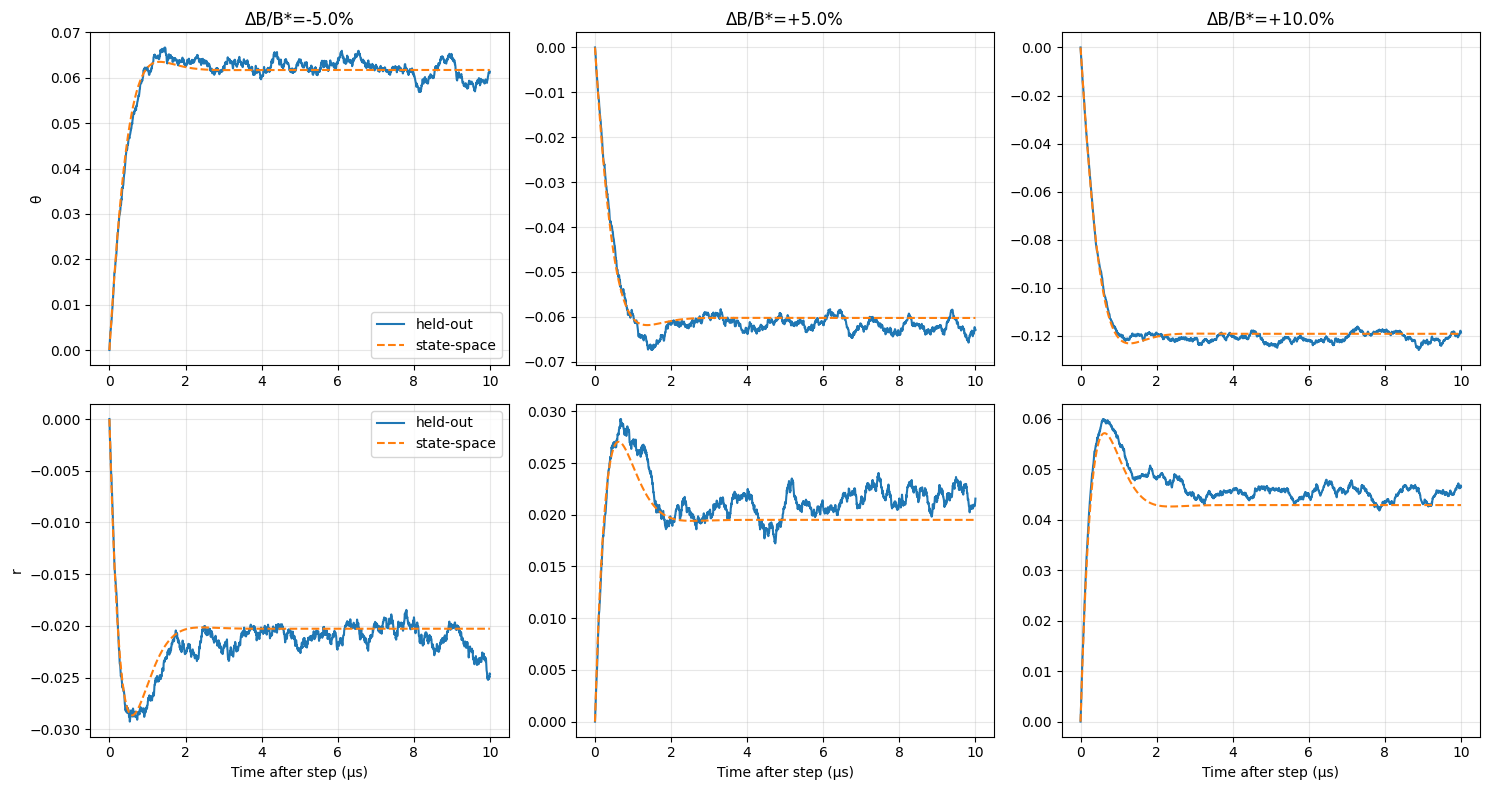

In [38]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

selected = [
    -0.05,
     0.05,
     0.10
]

for col, amp in enumerate(
    selected
):

    res = next(
        r
        for r
        in case1b_results
        if r["amp"] == amp
    )

    t = (
        res["t_test"]
        * 1e6
    )

    actual = (
        res["x_test"]
    )

    pred = (
        res["pred_test"]
    )

    axes[0,col].plot(
        t,
        actual[:,0],
        label="held-out"
    )

    axes[0,col].plot(
        t,
        pred[:,0],
        "--",
        label="state-space"
    )

    axes[1,col].plot(
        t,
        actual[:,1],
        label="held-out"
    )

    axes[1,col].plot(
        t,
        pred[:,1],
        "--",
        label="state-space"
    )

    axes[0,col].set_title(
        f"ΔB/B*={amp:+.1%}"
    )

    axes[1,col].set_xlabel(
        "Time after step (µs)"
    )

    axes[0,col].grid(
        alpha=0.3
    )

    axes[1,col].grid(
        alpha=0.3
    )

axes[0,0].set_ylabel(
    "θ"
)

axes[1,0].set_ylabel(
    "r"
)

axes[0,0].legend()
axes[1,0].legend()

plt.tight_layout()
plt.show()

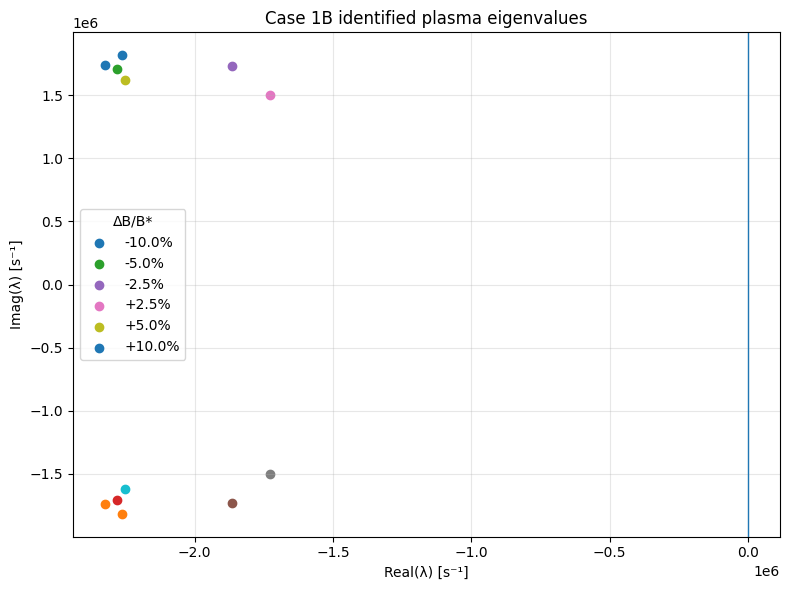

In [39]:
plt.figure(
    figsize=(8,6)
)

for _, row in (
    case1b_table.iterrows()
):

    plt.scatter(
        row["eig1_real"],
        row["eig1_imag"],
        label=f'{row["amp"]:+.1%}'
    )

    plt.scatter(
        row["eig2_real"],
        row["eig2_imag"]
    )

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Real(λ) [s⁻¹]"
)

plt.ylabel(
    "Imag(λ) [s⁻¹]"
)

plt.title(
    "Case 1B identified plasma eigenvalues"
)

plt.grid(
    alpha=0.3
)

plt.legend(
    title="ΔB/B*"
)

plt.tight_layout()
plt.show()

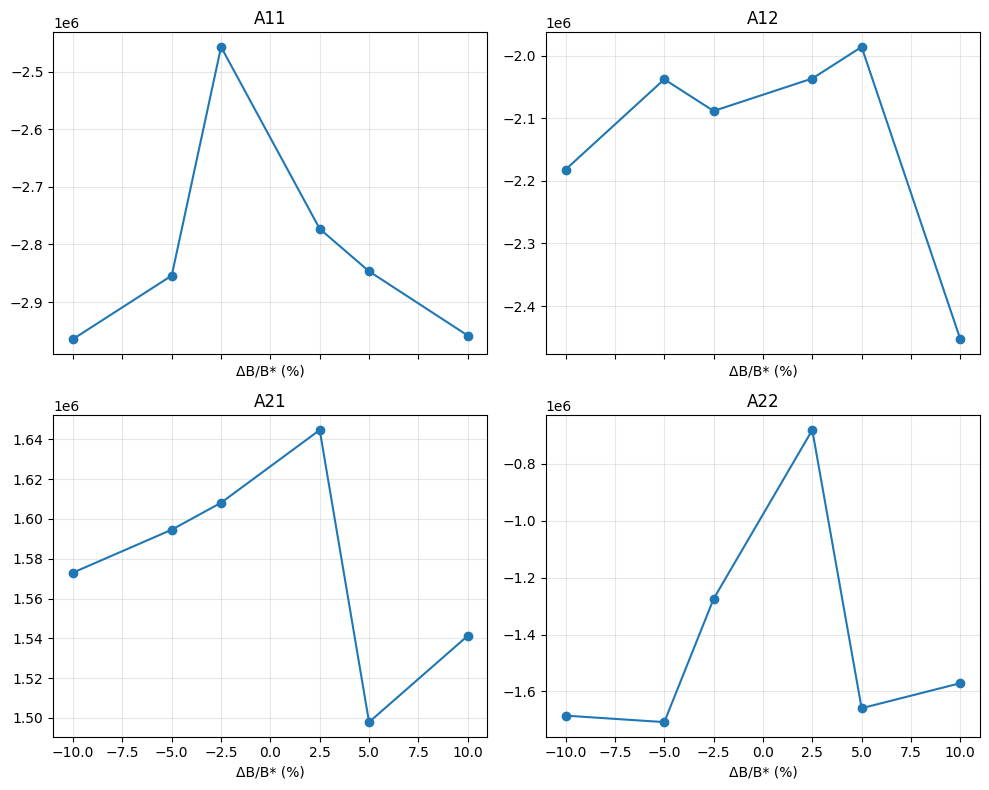

In [40]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10,8),
    sharex=True
)

entries = [
    ("A11", axes[0,0]),
    ("A12", axes[0,1]),
    ("A21", axes[1,0]),
    ("A22", axes[1,1])
]

for column, ax in entries:

    ax.plot(
        case1b_table["amp"]*100,
        case1b_table[column],
        marker="o"
    )

    ax.set_title(
        column
    )

    ax.set_xlabel(
        "ΔB/B* (%)"
    )

    ax.grid(
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [45]:
## Case 1B acceptance criteria

The coupled plasma state-space representation is accepted as a locally stable reduced model if:

1. all identified eigenvalues lie in the left half-plane;
2. the same eigenvalue topology is obtained for all six perturbations;
3. \(CV(\omega_n)<15\%\);
4. \(CV(\zeta)<20\%\);
5. positive/negative perturbation parameter splits remain below 15%;
6. median held-out NRMSE is below 0.5 for both state coordinates;
7. the identified state matrices vary smoothly rather than discontinuously with perturbation amplitude.

If criteria 1–5 are satisfied but criterion 6 fails, the result will be interpreted as evidence that the modal structure is identifiable but deterministic state prediction remains limited by stochastic variability.

SyntaxError: invalid syntax (4166019218.py, line 3)

In [42]:
CASE1B_CRITERIA = {

    "max_cv_wn":
        0.15,

    "max_cv_zeta":
        0.20,

    "max_sign_split":
        0.15,

    "max_median_nrmse":
        0.50
}


cv_fn = (
    coefficient_of_variation(
        case1b_table[
            "fn_Hz"
        ]
    )
)

cv_zeta = (
    coefficient_of_variation(
        case1b_table[
            "zeta"
        ]
    )
)

split_fn = (
    relative_split(
        positive["fn_Hz"],
        negative["fn_Hz"],
        case1b_table["fn_Hz"]
    )
)

split_zeta = (
    relative_split(
        positive["zeta"],
        negative["zeta"],
        case1b_table["zeta"]
    )
)

median_nrmse_theta = (
    np.median(
        case1b_table[
            "test_nrmse_theta"
        ]
    )
)

median_nrmse_r = (
    np.median(
        case1b_table[
            "test_nrmse_r"
        ]
    )
)


checks = {

    "all_stable":
        bool(
            case1b_table[
                "stable"
            ].all()
        ),

    "same_complex_topology":
        bool(
            case1b_table[
                "complex_pair"
            ].all()
        ),

    "cv_fn":
        float(cv_fn),

    "cv_zeta":
        float(cv_zeta),

    "sign_split_fn":
        float(split_fn),

    "sign_split_zeta":
        float(split_zeta),

    "median_nrmse_theta":
        float(
            median_nrmse_theta
        ),

    "median_nrmse_r":
        float(
            median_nrmse_r
        )
}


accepted = (

    checks["all_stable"]

    and

    checks[
        "same_complex_topology"
    ]

    and

    checks["cv_fn"]
    <=
    CASE1B_CRITERIA[
        "max_cv_wn"
    ]

    and

    checks["cv_zeta"]
    <=
    CASE1B_CRITERIA[
        "max_cv_zeta"
    ]

    and

    checks[
        "sign_split_fn"
    ]
    <=
    CASE1B_CRITERIA[
        "max_sign_split"
    ]

    and

    checks[
        "sign_split_zeta"
    ]
    <=
    CASE1B_CRITERIA[
        "max_sign_split"
    ]

    and

    checks[
        "median_nrmse_theta"
    ]
    <=
    CASE1B_CRITERIA[
        "max_median_nrmse"
    ]

    and

    checks[
        "median_nrmse_r"
    ]
    <=
    CASE1B_CRITERIA[
        "max_median_nrmse"
    ]
)


print(
    checks
)

print(
    "\nCASE 1B ACCEPTED:",
    accepted
)

{'all_stable': True, 'same_complex_topology': True, 'cv_fn': 0.09062313817245012, 'cv_zeta': 0.03960940957630216, 'sign_split_fn': 0.04111186013861197, 'sign_split_zeta': 0.005627151225366924, 'median_nrmse_theta': 0.2593177345866503, 'median_nrmse_r': 0.6315251167903668}

CASE 1B ACCEPTED: False


In [43]:
case1b_table.to_csv(
    OUT
    /
    "case1b_state_space_identification.csv",
    index=False
)


case1b_export = {

    "criteria":
        CASE1B_CRITERIA,

    "checks":
        checks,

    "accepted":
        bool(accepted),

    "interpretation":
        (
            "Coupled two-state linear plasma ROM "
            "identified from fresh MEA stochastic "
            "surrogate data."
        )
}


with open(
    OUT
    /
    "case1b_summary.json",
    "w"
) as f:

    json.dump(
        case1b_export,
        f,
        indent=2
    )


print(
    "Case 1B evidence exported."
)

Case 1B evidence exported.


In [44]:
from pathlib import Path
import json

OUT = Path("mea_case1_outputs")
OUT.mkdir(exist_ok=True)

print("Output directory:", OUT.resolve())

Output directory: /content/mea_case1_outputs


In [46]:
# Case 1C — Stochastic Noise-Floor and Transient-Window Validation

Case 1B recovered a stable complex-conjugate eigenstructure across all six
magnetic-field perturbations, but the full acceptance gate failed because the
held-out density-state NRMSE exceeded the pre-registered threshold.

Case 1C does not refit the acceptance criterion.

Instead, it asks:

1. Is the deterministic state-space prediction error larger than the intrinsic
   stochastic spread of the held-out plasma trajectories?

2. Does the identified modal structure remain stable when identification is
   restricted to the information-rich transient interval?

The primary noise-floor metric is

\[
E_{\mathrm{NF},j}
=
\frac{
\mathrm{RMSE}
\left(
\bar{x}_{j,\mathrm{test}},
\hat{x}_{j,\mathrm{ROM}}
\right)
}{
\sigma_{\mathrm{stochastic},j}
},
\]

where \(j\in\{\theta,r\}\).

Interpretation:

\[
E_{\mathrm{NF}}<1:
\quad
\text{ROM error is smaller than the intrinsic stochastic spread},
\]

\[
E_{\mathrm{NF}}\approx1:
\quad
\text{ROM error is comparable to the stochastic spread},
\]

\[
E_{\mathrm{NF}}>1:
\quad
\text{ROM discrepancy exceeds the stochastic spread}.
\]

Case 1A and Case 1B results remain unchanged regardless of the Case 1C outcome.

SyntaxError: invalid decimal literal (2113957955.py, line 3)

In [53]:
required_case1c = [
    "ensembles",
    "SIM",
    "STEP_AMPLITUDES",
    "prepare_state_condition",
    "identify_state_space",
    "simulate_identified_state_space",
    "modal_properties",
    "case1b_table"
]

missing = [
    name
    for name in required_case1c
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Case 1C prerequisites missing: "
        + ", ".join(missing)
    )

print("Case 1C prerequisites: OK")

Case 1C prerequisites: OK


In [54]:
def prepare_heldout_realizations(amp):

    runs = ensembles[float(amp)]

    heldout = runs[
        SIM["n_train"]:
    ]

    t_full = (
        heldout[0]["t_s"]
        .to_numpy()
    )

    mask = (
        t_full >= SIM["t_step_s"]
    )

    t = (
        t_full[mask]
        - SIM["t_step_s"]
    )

    u = (
        heldout[0]["u_B"]
        .to_numpy()[mask]
    )

    states = []

    for run in heldout:

        theta = (
            run["theta"]
            .to_numpy()[mask]
        )

        r = (
            run["r"]
            .to_numpy()[mask]
        )

        # Match Case 1B convention:
        # remove each realization's
        # value at the perturbation time.

        theta = theta - theta[0]
        r = r - r[0]

        states.append(
            np.column_stack([
                theta,
                r
            ])
        )

    states = np.stack(states)

    return t, u, states

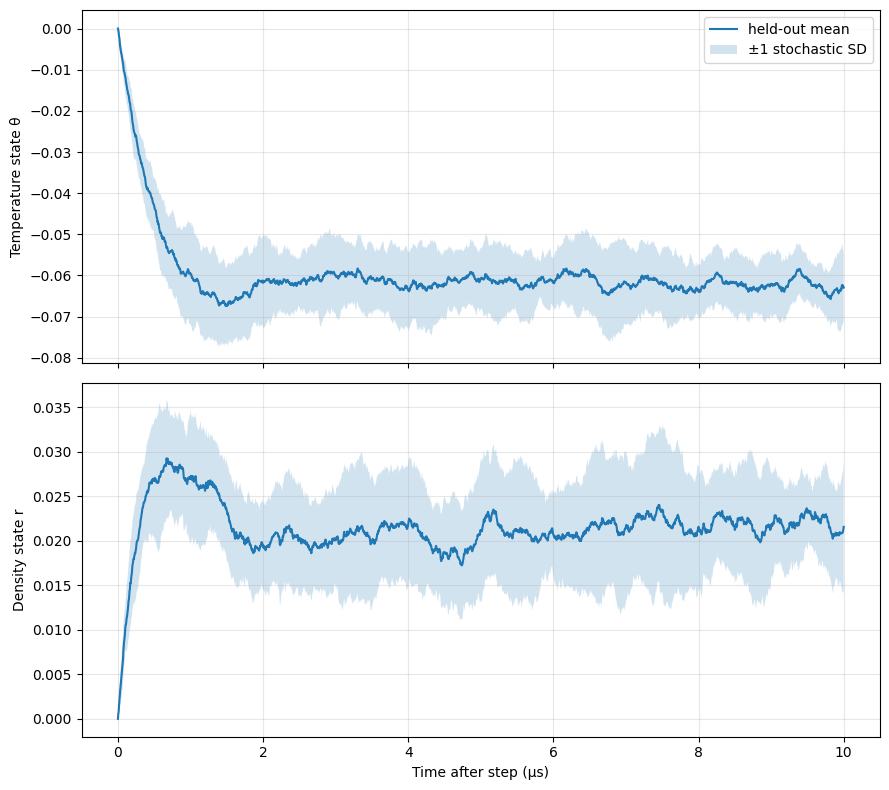

In [55]:
t_noise, u_noise, X_noise = (
    prepare_heldout_realizations(
        0.05
    )
)

mean_noise = X_noise.mean(axis=0)

std_noise = X_noise.std(
    axis=0,
    ddof=1
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True
)

labels = [
    "Temperature state θ",
    "Density state r"
]

for j, ax in enumerate(axes):

    ax.plot(
        t_noise*1e6,
        mean_noise[:,j],
        label="held-out mean"
    )

    ax.fill_between(
        t_noise*1e6,
        mean_noise[:,j]
        - std_noise[:,j],
        mean_noise[:,j]
        + std_noise[:,j],
        alpha=0.2,
        label="±1 stochastic SD"
    )

    ax.set_ylabel(
        labels[j]
    )

    ax.grid(
        alpha=0.3
    )

axes[1].set_xlabel(
    "Time after step (µs)"
)

axes[0].legend()

plt.tight_layout()
plt.show()

In [56]:
def noise_floor_metrics(
    amp,
    case1b_result
):

    t, u, X = (
        prepare_heldout_realizations(
            amp
        )
    )

    heldout_mean = (
        X.mean(axis=0)
    )

    stochastic_std = (
        X.std(
            axis=0,
            ddof=1
        )
    )

    A = case1b_result["A"]
    B = case1b_result["B"]

    _, pred = (
        simulate_identified_state_space(
            t,
            u,
            A,
            B,
            x0=heldout_mean[0]
        )
    )

    # Deterministic ROM error
    rom_rmse = np.sqrt(
        np.mean(
            (
                heldout_mean
                - pred
            )**2,
            axis=0
        )
    )

    # RMS stochastic spread
    stochastic_rms = np.sqrt(
        np.mean(
            stochastic_std**2,
            axis=0
        )
    )

    E_NF = (
        rom_rmse
        /
        stochastic_rms
    )

    return {
        "amp": amp,
        "rom_rmse_theta":
            rom_rmse[0],
        "rom_rmse_r":
            rom_rmse[1],

        "noise_rms_theta":
            stochastic_rms[0],
        "noise_rms_r":
            stochastic_rms[1],

        "E_NF_theta":
            E_NF[0],
        "E_NF_r":
            E_NF[1],

        "t": t,
        "mean": heldout_mean,
        "std": stochastic_std,
        "pred": pred
    }

In [57]:
case1c_noise_results = []

for amp in STEP_AMPLITUDES:

    res_b = next(
        res
        for res in case1b_results
        if res["amp"] == float(amp)
    )

    result = noise_floor_metrics(
        float(amp),
        res_b
    )

    case1c_noise_results.append(
        result
    )


case1c_noise_table = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in [
            "t",
            "mean",
            "std",
            "pred"
        ]
    }
    for result
    in case1c_noise_results
])

case1c_noise_table

,amp,rom_rmse_theta,rom_rmse_r,noise_rms_theta,noise_rms_r,E_NF_theta,E_NF_r
0,-0.100,0.004736,0.003023,0.008875,0.007744,0.533612,0.390448
1,-0.050,0.001781,0.001372,0.008655,0.006298,0.205768,0.217782
2,-0.025,0.003438,0.002544,0.008566,0.007053,0.401316,0.360715
3,0.025,0.002420,0.001490,0.012295,0.007713,0.196865,0.193224
4,0.050,0.002084,0.001985,0.008471,0.006395,0.245982,0.310407
5,0.100,0.002376,0.003030,0.008559,0.007131,0.277614,0.424954


In [58]:
print(
    "Median E_NF theta:",
    np.median(
        case1c_noise_table[
            "E_NF_theta"
        ]
    )
)

print(
    "Median E_NF r:",
    np.median(
        case1c_noise_table[
            "E_NF_r"
        ]
    )
)

print(
    "\nMaximum E_NF theta:",
    case1c_noise_table[
        "E_NF_theta"
    ].max()
)

print(
    "Maximum E_NF r:",
    case1c_noise_table[
        "E_NF_r"
    ].max()
)

Median E_NF theta: 0.2617978365611421
Median E_NF r: 0.3355608205085277

Maximum E_NF theta: 0.533611764186883
Maximum E_NF r: 0.4249539278862761


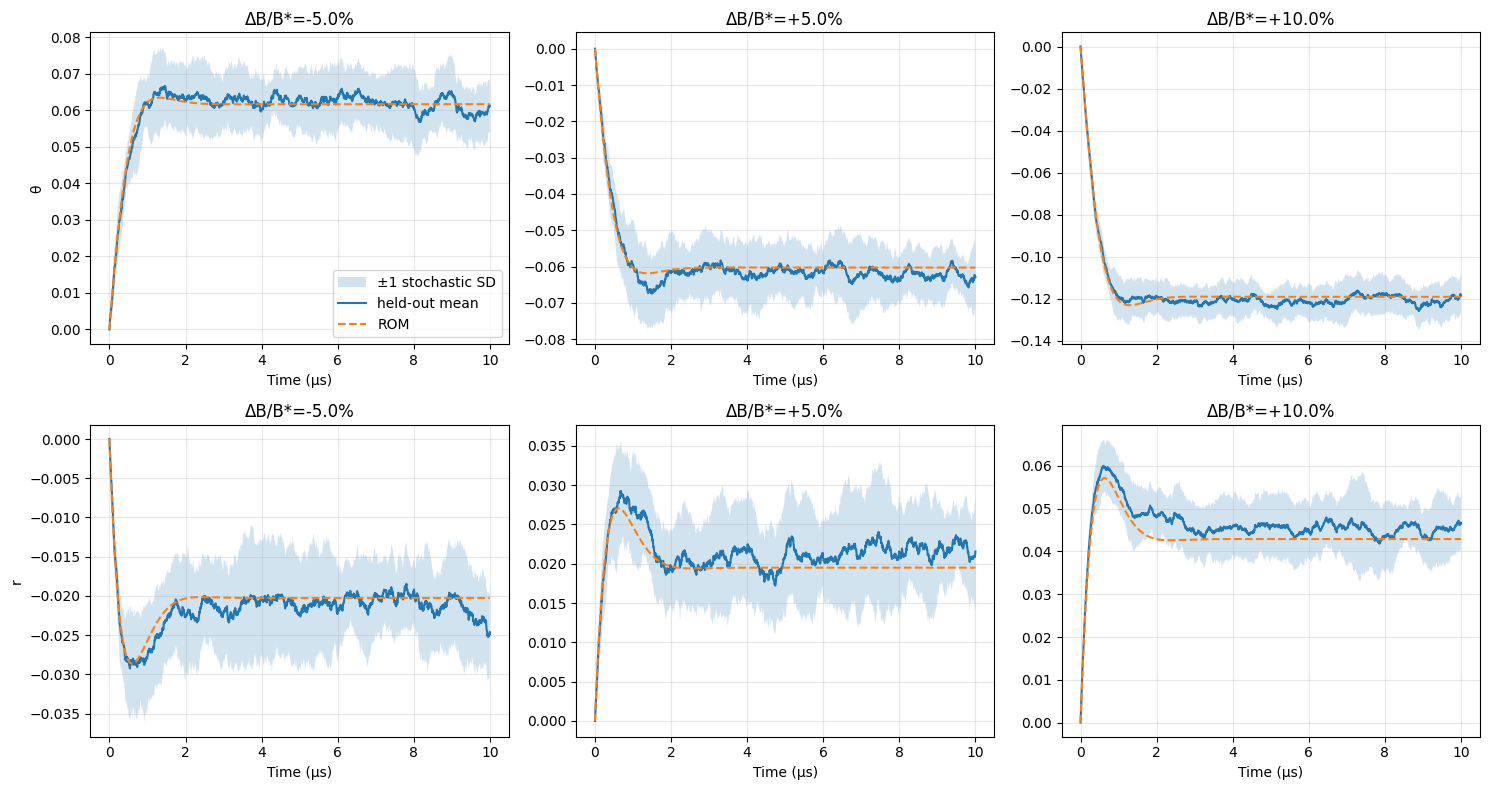

In [59]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

selected = [
    -0.05,
     0.05,
     0.10
]

for col, amp in enumerate(selected):

    result = next(
        r
        for r
        in case1c_noise_results
        if r["amp"] == amp
    )

    t = result["t"]*1e6

    for row in [0, 1]:

        mean = (
            result["mean"][:,row]
        )

        std = (
            result["std"][:,row]
        )

        pred = (
            result["pred"][:,row]
        )

        ax = axes[row,col]

        ax.fill_between(
            t,
            mean-std,
            mean+std,
            alpha=0.2,
            label="±1 stochastic SD"
        )

        ax.plot(
            t,
            mean,
            label="held-out mean"
        )

        ax.plot(
            t,
            pred,
            "--",
            label="ROM"
        )

        ax.grid(
            alpha=0.3
        )

        ax.set_title(
            f"ΔB/B*={amp:+.1%}"
        )

        ax.set_xlabel(
            "Time (µs)"
        )

axes[0,0].set_ylabel("θ")
axes[1,0].set_ylabel("r")

axes[0,0].legend()

plt.tight_layout()
plt.show()

In [60]:
def realization_noise_comparison(
    amp,
    case1b_result
):

    t, u, X = (
        prepare_heldout_realizations(
            amp
        )
    )

    mean = X.mean(axis=0)

    A = case1b_result["A"]
    B = case1b_result["B"]

    _, pred = (
        simulate_identified_state_space(
            t,
            u,
            A,
            B,
            x0=mean[0]
        )
    )

    rom_error = np.sqrt(
        np.mean(
            (
                pred - mean
            )**2,
            axis=0
        )
    )

    realization_errors = []

    for realization in X:

        err = np.sqrt(
            np.mean(
                (
                    realization
                    - mean
                )**2,
                axis=0
            )
        )

        realization_errors.append(
            err
        )

    realization_errors = (
        np.asarray(
            realization_errors
        )
    )

    percentiles = {}

    for state_idx, state in enumerate([
        "theta",
        "r"
    ]):

        distribution = (
            realization_errors[
                :,
                state_idx
            ]
        )

        percentile = (
            100
            *
            np.mean(
                distribution
                <=
                rom_error[
                    state_idx
                ]
            )
        )

        percentiles[state] = (
            percentile
        )

    return {
        "amp": amp,
        "rom_error": rom_error,
        "realization_errors":
            realization_errors,
        "percentile_theta":
            percentiles["theta"],
        "percentile_r":
            percentiles["r"]
    }

In [62]:
realization_results = []

for amp in STEP_AMPLITUDES:

    res_b = next(
        res
        for res in case1b_results
        if res["amp"] == float(amp)
    )

    realization_results.append(
        realization_noise_comparison(
            float(amp),
            res_b
        )
    )


realization_table = pd.DataFrame([
    {
        "amp":
            r["amp"],

        "ROM_error_theta":
            r["rom_error"][0],

        "ROM_error_r":
            r["rom_error"][1],

        "percentile_theta":
            r["percentile_theta"],

        "percentile_r":
            r["percentile_r"]
    }

    for r
    in realization_results
])

realization_table

,amp,ROM_error_theta,ROM_error_r,percentile_theta,percentile_r
0,-0.100,0.004736,0.003023,0.0,0.0
1,-0.050,0.001781,0.001372,0.0,0.0
2,-0.025,0.003438,0.002544,0.0,0.0
3,0.025,0.002420,0.001490,0.0,0.0
4,0.050,0.002084,0.001985,0.0,0.0
5,0.100,0.002376,0.003030,0.0,0.0


In [63]:
WINDOWS_US = [
    2.0,
    3.0,
    5.0,
    10.0
]


def evaluate_windowed_identification(
    amp,
    window_us
):

    t, x, u = (
        prepare_state_condition(
            amp,
            "train"
        )
    )

    mask = (
        t
        <=
        window_us*1e-6
    )

    t_w = t[mask]
    x_w = x[mask]
    u_w = u[mask]

    identified = (
        identify_state_space(
            t_w,
            x_w,
            u_w,
            window_length=101
        )
    )

    modal = (
        modal_properties(
            identified["A"]
        )
    )

    return {
        "amp":
            amp,

        "window_us":
            window_us,

        "A":
            identified["A"],

        "B":
            identified["B"],

        "stable":
            modal["stable"],

        "complex_pair":
            modal["complex_pair"],

        "fn_Hz":
            modal["fn_Hz"],

        "zeta":
            modal["zeta"]
    }

In [64]:
window_results = []

for window_us in WINDOWS_US:

    for amp in STEP_AMPLITUDES:

        window_results.append(
            evaluate_windowed_identification(
                float(amp),
                window_us
            )
        )


window_table = pd.DataFrame([
    {
        "amp":
            r["amp"],

        "window_us":
            r["window_us"],

        "stable":
            r["stable"],

        "complex_pair":
            r["complex_pair"],

        "fn_Hz":
            r["fn_Hz"],

        "zeta":
            r["zeta"]
    }

    for r
    in window_results
])

window_table

,amp,window_us,stable,complex_pair,fn_Hz,zeta
0,-0.100,2.0,True,True,477356.726112,0.798081
1,-0.050,2.0,True,True,474968.718823,0.826531
2,-0.025,2.0,True,True,420788.120418,0.802766
3,0.025,2.0,True,True,401651.185276,0.788705
4,0.050,2.0,True,True,439313.882739,0.806841
5,0.100,2.0,True,True,467421.410046,0.790415
6,-0.100,3.0,True,True,462433.612891,0.802771
7,-0.050,3.0,True,True,483483.919416,0.801270
8,-0.025,3.0,True,True,421017.857058,0.789445
9,0.025,3.0,True,True,357646.234516,0.807541


In [97]:
window_summary_rows = []

for window_us in WINDOWS_US:

    d = window_table[
        window_table[
            "window_us"
        ]
        == window_us
    ]

    window_summary_rows.append({

        "window_us":
            window_us,

        "all_stable":
            bool(
                d["stable"].all()
            ),

        "all_complex":
            bool(
                d[
                    "complex_pair"
                ].all()
            ),

        "mean_fn_Hz":
            d["fn_Hz"].mean(),

        "cv_fn":
            d["fn_Hz"].std()
            /
            d["fn_Hz"].mean(),

        "mean_zeta":
            d["zeta"].mean(),

        "cv_zeta":
            d["zeta"].std()
            /
            d["zeta"].mean()
    })


window_summary = (
    pd.DataFrame(
        window_summary_rows
    )
)

window_summary

,window_us,all_stable,all_complex,mean_fn_Hz,cv_fn,mean_zeta,cv_zeta
0,2.0,True,True,446916.673902,0.070214,0.802223,0.017199
1,3.0,True,True,440581.290854,0.103540,0.798031,0.010638
2,5.0,True,True,441908.080706,0.075252,0.788810,0.020779
3,10.0,True,True,431508.275937,0.090391,0.780006,0.039629


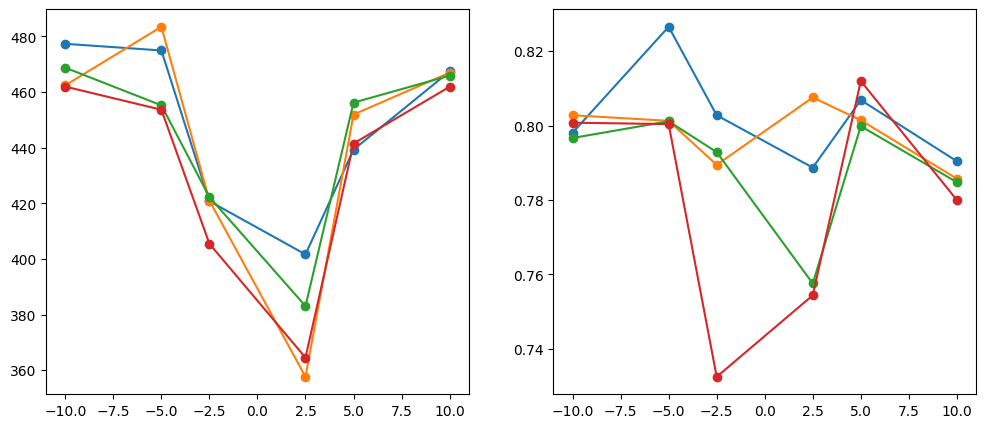

In [98]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for window_us in WINDOWS_US:

    d = window_table[
        window_table[
            "window_us"
        ]
        == window_us
    ]

    axes[0].plot(
        d["amp"]*100,
        d["fn_Hz"]/1e3,
        marker="o",
        label=f"{window_us:g} µs"
    )

    axes[1].plot(
        d["amp"]*100,
        d["zeta"],
        marker="o",
        label=f"{window_us:g} µs"
    )

In [79]:
# Case 1D — Dimensionless Plasma Characterization and Final Case-1 Parameter Extraction

Cases 1A–1C established the following evidence chain:

- **Case 1A:** independent scalar second-order ROMs were not accepted under the pre-registered predictive criterion.
- **Case 1B:** a coupled two-state linear model recovered a stable complex-conjugate eigenstructure across all six magnetic perturbations.
- **Case 1C:** the deterministic ROM discrepancy remained below the stochastic noise floor, and the same stable complex modal topology persisted across 2, 3, 5, and 10 µs identification windows.

Case 1D does not perform further model selection.

Its objectives are to:

1. extract the nominal plasma modal parameters from the primary Case 1B identification;
2. quantify variation across the pre-registered magnetic-field perturbations;
3. quantify window-dependent robustness separately;
4. construct the dimensionless frequency variable
   \[
   \Omega_p=\omega/\omega_{n,p};
   \]
5. characterize damping and the damped modal frequency;
6. define the plasma magnetic-coupling parameter
   \[
   \Pi_{C,p}=\omega_{ce}/\nu_{en}
   \]
   without assigning an unsupported collision frequency;
7. define the Case-1 validity envelope around \(B_\ast=0.4~\mathrm{T}\);
8. export the final Case-1 parameter record for later cross-domain comparison.

The plasma ROM is interpreted as a **coupled local modal system**, not as a literal mechanical mass–spring oscillator.

SyntaxError: invalid decimal literal (3871366794.py, line 3)

In [99]:
required_case1d = [
    "BASELINE",
    "STEP_AMPLITUDES",
    "case1b_table",
    "case1c_noise_table",
    "window_table",
    "window_summary"
]

missing = [
    name
    for name in required_case1d
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Case 1D prerequisites missing: "
        + ", ".join(missing)
    )

print("Case 1D prerequisites: OK")

Case 1D prerequisites: OK


In [100]:
primary = case1b_table.copy()

PRIMARY_WINDOW_US = 10.0

def describe_parameter(series):
    s = np.asarray(series, dtype=float)

    return {
        "mean": float(np.mean(s)),
        "median": float(np.median(s)),
        "std": float(np.std(s, ddof=1)),
        "min": float(np.min(s)),
        "max": float(np.max(s)),
        "cv": float(
            np.std(s, ddof=1)
            /
            abs(np.mean(s))
        )
    }


fn_stats = describe_parameter(
    primary["fn_Hz"]
)

wn_stats = describe_parameter(
    primary["wn_rad_s"]
)

zeta_stats = describe_parameter(
    primary["zeta"]
)


print("Primary Case 1B frequency statistics:")
print(fn_stats)

print("\nPrimary Case 1B angular-frequency statistics:")
print(wn_stats)

print("\nPrimary Case 1B damping statistics:")
print(zeta_stats)

Primary Case 1B frequency statistics:
{'mean': 431479.5832547581, 'median': 447570.53966048977, 'std': 39102.033891887135, 'min': 364285.16493131575, 'max': 462000.31725631584, 'cv': 0.09062313817245012}

Primary Case 1B angular-frequency statistics:
{'mean': 2711066.1778542674, 'median': 2812168.6387212276, 'std': 245685.32483034342, 'min': 2288871.1959199356, 'max': 2902833.605297191, 'cv': 0.09062313817245009}

Primary Case 1B damping statistics:
{'mean': 0.7800088823828552, 'median': 0.7901529090325825, 'std': 0.030895691295456208, 'min': 0.7324241189728685, 'max': 0.8119707005428363, 'cv': 0.03960940957630216}


In [101]:
FN_NOM_HZ = fn_stats["mean"]
FN_STD_HZ = fn_stats["std"]

WN_NOM = wn_stats["mean"]
WN_STD = wn_stats["std"]

ZETA_NOM = zeta_stats["mean"]
ZETA_STD = zeta_stats["std"]


print(
    f"Nominal fn,p = "
    f"{FN_NOM_HZ/1e3:.2f} ± "
    f"{FN_STD_HZ/1e3:.2f} kHz"
)

print(
    f"Nominal omega_n,p = "
    f"{WN_NOM:.4e} ± "
    f"{WN_STD:.4e} rad/s"
)

print(
    f"Nominal zeta_p = "
    f"{ZETA_NOM:.4f} ± "
    f"{ZETA_STD:.4f}"
)

Nominal fn,p = 431.48 ± 39.10 kHz
Nominal omega_n,p = 2.7111e+06 ± 2.4569e+05 rad/s
Nominal zeta_p = 0.7800 ± 0.0309


In [102]:
case1d_modal = primary[
    [
        "amp",
        "wn_rad_s",
        "fn_Hz",
        "zeta"
    ]
].copy()

case1d_modal[
    "sigma_decay_s_inv"
] = (
    case1d_modal["zeta"]
    *
    case1d_modal["wn_rad_s"]
)

case1d_modal[
    "omega_d_rad_s"
] = (
    case1d_modal["wn_rad_s"]
    *
    np.sqrt(
        np.maximum(
            0.0,
            1.0
            -
            case1d_modal["zeta"]**2
        )
    )
)

case1d_modal[
    "f_d_Hz"
] = (
    case1d_modal[
        "omega_d_rad_s"
    ]
    /
    (2*np.pi)
)

case1d_modal[
    "decay_time_s"
] = (
    1.0
    /
    case1d_modal[
        "sigma_decay_s_inv"
    ]
)

case1d_modal

,amp,wn_rad_s,fn_Hz,zeta,sigma_decay_s_inv,omega_d_rad_s,f_d_Hz,decay_time_s
0,-0.100,2.902765e+06,461989.378749,0.800764,2.324429e+06,1.738698e+06,276722.459728,4.302131e-07
1,-0.050,2.850029e+06,453596.204163,0.800255,2.280749e+06,1.709049e+06,272003.551860,4.384524e-07
2,-0.025,2.547590e+06,405461.559271,0.732424,1.865916e+06,1.734523e+06,276057.962921,5.359297e-07
3,0.025,2.288871e+06,364285.164931,0.754589,1.727157e+06,1.501953e+06,239043.188501,5.789863e-07
4,0.050,2.774308e+06,441544.875157,0.811971,2.252657e+06,1.619359e+06,257728.946117,4.439202e-07
5,0.100,2.902834e+06,462000.317256,0.780051,2.264358e+06,1.816349e+06,289080.952972,4.416262e-07


In [103]:
fd_stats = describe_parameter(
    case1d_modal[
        "f_d_Hz"
    ]
)

sigma_stats = describe_parameter(
    case1d_modal[
        "sigma_decay_s_inv"
    ]
)

tau_decay_stats = describe_parameter(
    case1d_modal[
        "decay_time_s"
    ]
)


print(
    f"Damped frequency fd,p = "
    f"{fd_stats['mean']/1e3:.2f} ± "
    f"{fd_stats['std']/1e3:.2f} kHz"
)

print(
    f"Decay rate sigma = "
    f"{sigma_stats['mean']:.4e} ± "
    f"{sigma_stats['std']:.4e} 1/s"
)

print(
    f"Modal decay time = "
    f"{tau_decay_stats['mean']*1e6:.3f} ± "
    f"{tau_decay_stats['std']*1e6:.3f} µs"
)

Damped frequency fd,p = 268.44 ± 17.57 kHz
Decay rate sigma = 2.1192e+06 ± 2.5493e+05 1/s
Modal decay time = 0.478 ± 0.063 µs


In [104]:
case1d_modal[
    "Q_modal_equiv"
] = (
    1.0
    /
    (
        2.0
        *
        case1d_modal["zeta"]
    )
)

Q_stats = describe_parameter(
    case1d_modal[
        "Q_modal_equiv"
    ]
)

print(
    f"Pole-based Q-equivalent = "
    f"{Q_stats['mean']:.3f} ± "
    f"{Q_stats['std']:.3f}"
)

print(
    "\nCAUTION:"
    "\nThis is a pole-based Q-equivalent."
    "\nThe plasma mode is not lightly damped,"
    "\nso this should not be described as a"
    "\nsharp resonance quality factor."
)

Pole-based Q-equivalent = 0.642 ± 0.026

CAUTION:
This is a pole-based Q-equivalent.
The plasma mode is not lightly damped,
so this should not be described as a
sharp resonance quality factor.


In [105]:
ZETA_RESONANCE_LIMIT = 1 / np.sqrt(2)

case1d_modal[
    "finite_amplitude_resonance"
] = (
    case1d_modal["zeta"]
    <
    ZETA_RESONANCE_LIMIT
)

print(
    "Conditions with classical finite "
    "amplitude-resonance peak:",
    int(
        case1d_modal[
            "finite_amplitude_resonance"
        ].sum()
    ),
    "/",
    len(case1d_modal)
)

print(
    "Resonance threshold zeta <",
    ZETA_RESONANCE_LIMIT
)

Conditions with classical finite amplitude-resonance peak: 0 / 6
Resonance threshold zeta < 0.7071067811865475


In [106]:
OMEGA_GRID = np.linspace(
    0.0,
    3.0,
    601
)

# Modal-equivalent normalized second-order
# denominator, used only for cross-domain
# response characterization.

H_MODAL = (
    1.0
    /
    np.sqrt(
        (
            1.0
            -
            OMEGA_GRID**2
        )**2
        +
        (
            2.0
            *
            ZETA_NOM
            *
            OMEGA_GRID
        )**2
    )
)

phase_modal = -np.arctan2(
    2.0
    *
    ZETA_NOM
    *
    OMEGA_GRID,

    1.0
    -
    OMEGA_GRID**2
)

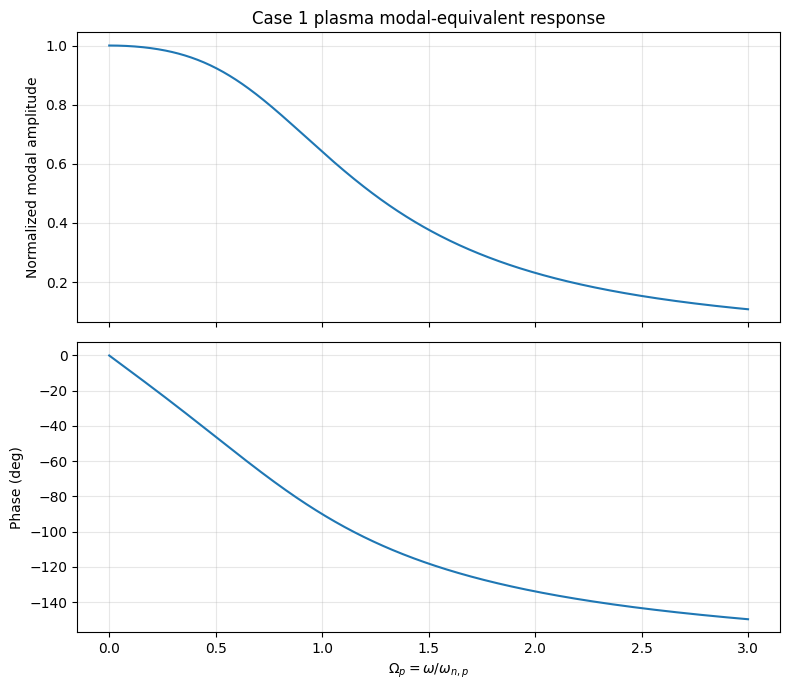

In [107]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True
)

axes[0].plot(
    OMEGA_GRID,
    H_MODAL
)

axes[0].set_ylabel(
    "Normalized modal amplitude"
)

axes[0].set_title(
    "Case 1 plasma modal-equivalent response"
)

axes[1].plot(
    OMEGA_GRID,
    phase_modal
    *
    180
    /
    np.pi
)

axes[1].set_ylabel(
    "Phase (deg)"
)

axes[1].set_xlabel(
    r"$\Omega_p=\omega/\omega_{n,p}$"
)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
E_CHARGE = 1.602176634e-19
M_E = 9.1093837015e-31

def omega_ce(B_T):
    return (
        E_CHARGE
        *
        B_T
        /
        M_E
    )


B_STAR = BASELINE[
    "B_star_T"
]

OMEGA_CE_STAR = omega_ce(
    B_STAR
)

F_CE_STAR = (
    OMEGA_CE_STAR
    /
    (2*np.pi)
)


print(
    f"B* = {B_STAR:.3f} T"
)

print(
    f"omega_ce(B*) = "
    f"{OMEGA_CE_STAR:.4e} rad/s"
)

print(
    f"f_ce(B*) = "
    f"{F_CE_STAR/1e9:.3f} GHz"
)

print(
    "\nTherefore:"
)

print(
    "Pi_C,p* = "
    f"{OMEGA_CE_STAR:.4e} / nu_en"
)

B* = 0.400 T
omega_ce(B*) = 7.0353e+10 rad/s
f_ce(B*) = 11.197 GHz

Therefore:
Pi_C,p* = 7.0353e+10 / nu_en


In [109]:
B_values = (
    B_STAR
    *
    (
        1.0
        +
        STEP_AMPLITUDES
    )
)

coupling_table = pd.DataFrame({
    "amp": STEP_AMPLITUDES,
    "B_T": B_values,
    "Pi_B": B_values / B_STAR,
    "omega_ce_rad_s": [
        omega_ce(B)
        for B in B_values
    ]
})

# Symbolic coefficient:
# Pi_C = omega_ce / nu_en

coupling_table[
    "PiC_coefficient_rad_s"
] = coupling_table[
    "omega_ce_rad_s"
]

coupling_table

,amp,B_T,Pi_B,omega_ce_rad_s,PiC_coefficient_rad_s
0,-0.100,0.36,0.900,6.331752e+10,6.331752e+10
1,-0.050,0.38,0.950,6.683516e+10,6.683516e+10
2,-0.025,0.39,0.975,6.859398e+10,6.859398e+10
3,0.025,0.41,1.025,7.211162e+10,7.211162e+10
4,0.050,0.42,1.050,7.387044e+10,7.387044e+10
5,0.100,0.44,1.100,7.738808e+10,7.738808e+10


In [110]:
P_RF_STAR = BASELINE[
    "rf_power_W"
]

PI_F_NOM = 1.0

print(
    f"Nominal RF power = "
    f"{P_RF_STAR:.1f} W"
)

print(
    f"Case-1 forcing ratio "
    f"Pi_F,p = {PI_F_NOM:.1f}"
)

print(
    "No RF-power sweep was used "
    "for Case-1 modal identification."
)

Nominal RF power = 100.0 W
Case-1 forcing ratio Pi_F,p = 1.0
No RF-power sweep was used for Case-1 modal identification.


In [111]:
B_MIN = (
    B_STAR
    *
    (
        1.0
        +
        STEP_AMPLITUDES.min()
    )
)

B_MAX = (
    B_STAR
    *
    (
        1.0
        +
        STEP_AMPLITUDES.max()
    )
)


print(
    f"Validated local magnetic interval: "
    f"{B_MIN:.3f} to "
    f"{B_MAX:.3f} T"
)

print(
    f"Equivalent normalized interval: "
    f"{B_MIN/B_STAR:.2f} <= Pi_B <= "
    f"{B_MAX/B_STAR:.2f}"
)

Validated local magnetic interval: 0.360 to 0.440 T
Equivalent normalized interval: 0.90 <= Pi_B <= 1.10


In [112]:
noise_summary = {
    "median_E_NF_theta":
        float(
            np.median(
                case1c_noise_table[
                    "E_NF_theta"
                ]
            )
        ),

    "median_E_NF_r":
        float(
            np.median(
                case1c_noise_table[
                    "E_NF_r"
                ]
            )
        ),

    "max_E_NF_theta":
        float(
            case1c_noise_table[
                "E_NF_theta"
            ].max()
        ),

    "max_E_NF_r":
        float(
            case1c_noise_table[
                "E_NF_r"
            ].max()
        )
}

noise_summary

{'median_E_NF_theta': 0.2617978365611421,
 'median_E_NF_r': 0.3355608205085277,
 'max_E_NF_theta': 0.533611764186883,
 'max_E_NF_r': 0.4249539278862761}

In [113]:
window_robustness = {
    "mean_fn_min_Hz":
        float(
            window_summary[
                "mean_fn_Hz"
            ].min()
        ),

    "mean_fn_max_Hz":
        float(
            window_summary[
                "mean_fn_Hz"
            ].max()
        ),

    "mean_zeta_min":
        float(
            window_summary[
                "mean_zeta"
            ].min()
        ),

    "mean_zeta_max":
        float(
            window_summary[
                "mean_zeta"
            ].max()
        ),

    "all_windows_stable":
        bool(
            window_summary[
                "all_stable"
            ].all()
        ),

    "all_windows_complex":
        bool(
            window_summary[
                "all_complex"
            ].all()
        )
}

window_robustness

{'mean_fn_min_Hz': 431508.27593656833,
 'mean_fn_max_Hz': 446916.6739023414,
 'mean_zeta_min': 0.7800062961714228,
 'mean_zeta_max': 0.8022233525799161,
 'all_windows_stable': True,
 'all_windows_complex': True}

In [114]:
case1_final = pd.DataFrame([
    {
        "domain":
            "Magnetically filtered plasma",

        "reduced_state":
            "[theta, r]^T",

        "B_star_T":
            B_STAR,

        "B_valid_min_T":
            B_MIN,

        "B_valid_max_T":
            B_MAX,

        "fn_nom_Hz":
            FN_NOM_HZ,

        "fn_std_Hz":
            FN_STD_HZ,

        "wn_nom_rad_s":
            WN_NOM,

        "wn_std_rad_s":
            WN_STD,

        "zeta_nom":
            ZETA_NOM,

        "zeta_std":
            ZETA_STD,

        "fd_nom_Hz":
            fd_stats["mean"],

        "Q_modal_equiv":
            Q_stats["mean"],

        "Pi_B_nom":
            1.0,

        "Pi_B_min":
            B_MIN/B_STAR,

        "Pi_B_max":
            B_MAX/B_STAR,

        "Pi_F_nom":
            PI_F_NOM,

        "omega_ce_star_rad_s":
            OMEGA_CE_STAR,

        "Pi_C_definition":
            "omega_ce / nu_en",

        "median_E_NF_theta":
            noise_summary[
                "median_E_NF_theta"
            ],

        "median_E_NF_r":
            noise_summary[
                "median_E_NF_r"
            ],

        "modal_topology":
            "stable complex-conjugate pair",

        "interpretation":
            (
                "Local coupled plasma modal ROM; "
                "not a literal mechanical oscillator."
            )
    }
])

case1_final.T

,0
domain,Magnetically filtered plasma
reduced_state,"[theta, r]^T"
B_star_T,0.4
B_valid_min_T,0.36
B_valid_max_T,0.44
fn_nom_Hz,431479.583255
fn_std_Hz,39102.033892
wn_nom_rad_s,2711066.177854
wn_std_rad_s,245685.32483
zeta_nom,0.780009


In [68]:
print("CASE 1 FINAL CHARACTERIZATION")
print("--------------------------------")

print(
    f"Validated B range: "
    f"{B_MIN:.3f}–{B_MAX:.3f} T"
)

print(
    f"Natural modal frequency: "
    f"{FN_NOM_HZ/1e3:.1f} ± "
    f"{FN_STD_HZ/1e3:.1f} kHz"
)

print(
    f"Damping ratio: "
    f"{ZETA_NOM:.3f} ± "
    f"{ZETA_STD:.3f}"
)

print(
    f"Damped modal frequency: "
    f"{fd_stats['mean']/1e3:.1f} ± "
    f"{fd_stats['std']/1e3:.1f} kHz"
)

print(
    f"Pole Q-equivalent: "
    f"{Q_stats['mean']:.3f}"
)

print(
    f"Median E_NF theta: "
    f"{noise_summary['median_E_NF_theta']:.3f}"
)

print(
    f"Median E_NF r: "
    f"{noise_summary['median_E_NF_r']:.3f}"
)

print(
    f"Electron cyclotron frequency at B*: "
    f"{F_CE_STAR/1e9:.2f} GHz"
)

print(
    "Pi_C,p = omega_ce / nu_en "
    "(nu_en not yet assigned)"
)

print(
    "Pi_F,p = 1.0 "
    "(RF power held fixed)"
)

print(
    "\nModal interpretation: "
    "stable, underdamped, strongly damped "
    "complex-conjugate mode."
)

CASE 1 FINAL CHARACTERIZATION
--------------------------------


NameError: name 'B_MIN' is not defined

In [115]:
from pathlib import Path
import json

OUT = Path(
    "mea_case1_outputs"
)

OUT.mkdir(
    exist_ok=True
)


case1d_modal.to_csv(
    OUT
    /
    "case1d_modal_parameters.csv",
    index=False
)

coupling_table.to_csv(
    OUT
    /
    "case1d_magnetic_coupling.csv",
    index=False
)

case1_final.to_csv(
    OUT
    /
    "case1_final_characterization.csv",
    index=False
)


case1d_summary = {

    "primary_identification_window_us":
        PRIMARY_WINDOW_US,

    "frequency_Hz":
        fn_stats,

    "angular_frequency_rad_s":
        wn_stats,

    "damping_ratio":
        zeta_stats,

    "damped_frequency_Hz":
        fd_stats,

    "Q_modal_equivalent":
        Q_stats,

    "noise_floor":
        noise_summary,

    "window_robustness":
        window_robustness,

    "magnetic_field_T": {
        "nominal":
            B_STAR,

        "validated_min":
            B_MIN,

        "validated_max":
            B_MAX
    },

    "dimensionless": {
        "Pi_B_nominal":
            1.0,

        "Pi_B_range":
            [
                B_MIN/B_STAR,
                B_MAX/B_STAR
            ],

        "Pi_F_nominal":
            PI_F_NOM,

        "Pi_C_definition":
            "omega_ce / nu_en",

        "omega_ce_star_rad_s":
            OMEGA_CE_STAR
    },

    "status":
        "CASE_1_CHARACTERIZED",

    "interpretation":
        (
            "Validated local coupled plasma modal ROM. "
            "Stable complex-conjugate eigenstructure; "
            "deterministic prediction error below "
            "stochastic noise floor. "
            "No literal mechanical inertia asserted."
        )
}


with open(
    OUT
    /
    "case1d_summary.json",
    "w"
) as f:

    json.dump(
        case1d_summary,
        f,
        indent=2
    )


print(
    "Case 1D evidence exported to:",
    OUT.resolve()
)

Case 1D evidence exported to: /content/mea_case1_outputs


In [116]:
# ============================================================
# MEA PUBLICATION FIGURES
# Figure 2 — Plasma transient response and ROM validation
# Preflight: inspect existing Case 1 objects only
# ============================================================

required_candidates = [
    "ensembles",
    "STEP_AMPLITUDES",
    "prepare_state_condition",
    "smooth_and_differentiate",
    "BASELINE",
    "SURROGATE",
    "SIM",
    "SEED",
]

print("Available Case 1 objects:")
for name in required_candidates:
    print(f"{name:28s}: {name in globals()}")

# Look for likely fitted/state-space objects already created by Case 1B
possible_fit_objects = [
    "A_hat",
    "B_hat",
    "A_est",
    "B_est",
    "state_space_results",
    "case1b_results",
    "identified_models",
    "model_results",
]

print("\nPossible fitted-model objects:")
for name in possible_fit_objects:
    if name in globals():
        obj = globals()[name]
        print(f"{name:28s}: {type(obj).__name__}")

Available Case 1 objects:
ensembles                   : True
STEP_AMPLITUDES             : True
prepare_state_condition     : True
smooth_and_differentiate    : True
BASELINE                    : True
SURROGATE                   : True
SIM                         : True
SEED                        : True

Possible fitted-model objects:
case1b_results              : list


In [117]:
# ============================================================
# MEA FIGURE 2 — Inspect retained Case 1B results
# ============================================================

print("case1b_results type:", type(case1b_results))
print("number of entries:", len(case1b_results))

for i, item in enumerate(case1b_results[:3]):
    print(f"\n--- entry {i} ---")
    print("type:", type(item))

    if isinstance(item, dict):
        print("keys:", sorted(item.keys()))

        for key, value in item.items():
            if hasattr(value, "shape"):
                print(f"{key:30s} shape={value.shape}")
            elif isinstance(value, (int, float, str, bool)):
                print(f"{key:30s} {value}")
            else:
                print(f"{key:30s} type={type(value).__name__}")
    else:
        print(item)

case1b_results type: <class 'list'>
number of entries: 6

--- entry 0 ---
type: <class 'dict'>
keys: ['A', 'B', 'amp', 'modal', 'pred_test', 't_test', 'test_nrmse', 'test_rmse', 'train_rmse', 'x_test']
amp                            -0.1
A                              shape=(2, 2)
B                              shape=(2, 1)
modal                          type=dict
train_rmse                     shape=(2,)
test_rmse                      shape=(2,)
test_nrmse                     shape=(2,)
t_test                         shape=(2001,)
x_test                         shape=(2001, 2)
pred_test                      shape=(2001, 2)

--- entry 1 ---
type: <class 'dict'>
keys: ['A', 'B', 'amp', 'modal', 'pred_test', 't_test', 'test_nrmse', 'test_rmse', 'train_rmse', 'x_test']
amp                            -0.05
A                              shape=(2, 2)
B                              shape=(2, 1)
modal                          type=dict
train_rmse                     shape=(2,)
test_rmse      

In [118]:
# ============================================================
# Inspect Case 1 ensemble storage
# ============================================================

amps = sorted(float(a) for a in STEP_AMPLITUDES)

print("Perturbations:", amps)
print("ensembles type:", type(ensembles))

first_condition = ensembles[amps[0]]

print("\nFirst condition type:", type(first_condition))

if hasattr(first_condition, "shape"):
    print("shape:", first_condition.shape)
elif isinstance(first_condition, (list, tuple)):
    print("number of realizations:", len(first_condition))
    print("first realization type:", type(first_condition[0]))

    first_run = first_condition[0]

    if isinstance(first_run, dict):
        print("first realization keys:", sorted(first_run.keys()))
        for key, value in first_run.items():
            if hasattr(value, "shape"):
                print(f"{key:25s} shape={value.shape}")
            else:
                print(f"{key:25s} type={type(value).__name__}")
    else:
        print(first_run)
elif isinstance(first_condition, dict):
    print("keys:", sorted(first_condition.keys()))
    for key, value in first_condition.items():
        if hasattr(value, "shape"):
            print(f"{key:25s} shape={value.shape}")
        else:
            print(f"{key:25s} type={type(value).__name__}")

Perturbations: [-0.1, -0.05, -0.025, 0.025, 0.05, 0.1]
ensembles type: <class 'dict'>

First condition type: <class 'list'>
number of realizations: 50
first realization type: <class 'pandas.core.frame.DataFrame'>
               t_s   B_T  u_B     theta         r  Te_cold_eV  \
0     0.000000e+00  0.40  0.0  0.000000  0.000000    0.800000   
1     5.000000e-09  0.40  0.0  0.001129  0.000906    0.800903   
2     1.000000e-08  0.40  0.0  0.001210  0.000630    0.800968   
3     1.500000e-08  0.40  0.0  0.000281  0.000979    0.800225   
4     2.000000e-08  0.40  0.0  0.000982  0.001808    0.800786   
...            ...   ...  ...       ...       ...         ...   
2396  1.198000e-05  0.36 -0.1  0.123780 -0.042473    0.899024   
2397  1.198500e-05  0.36 -0.1  0.126338 -0.041112    0.901071   
2398  1.199000e-05  0.36 -0.1  0.126226 -0.041089    0.900981   
2399  1.199500e-05  0.36 -0.1  0.125842 -0.040397    0.900674   
2400  1.200000e-05  0.36 -0.1  0.126021 -0.040013    0.900817   

      

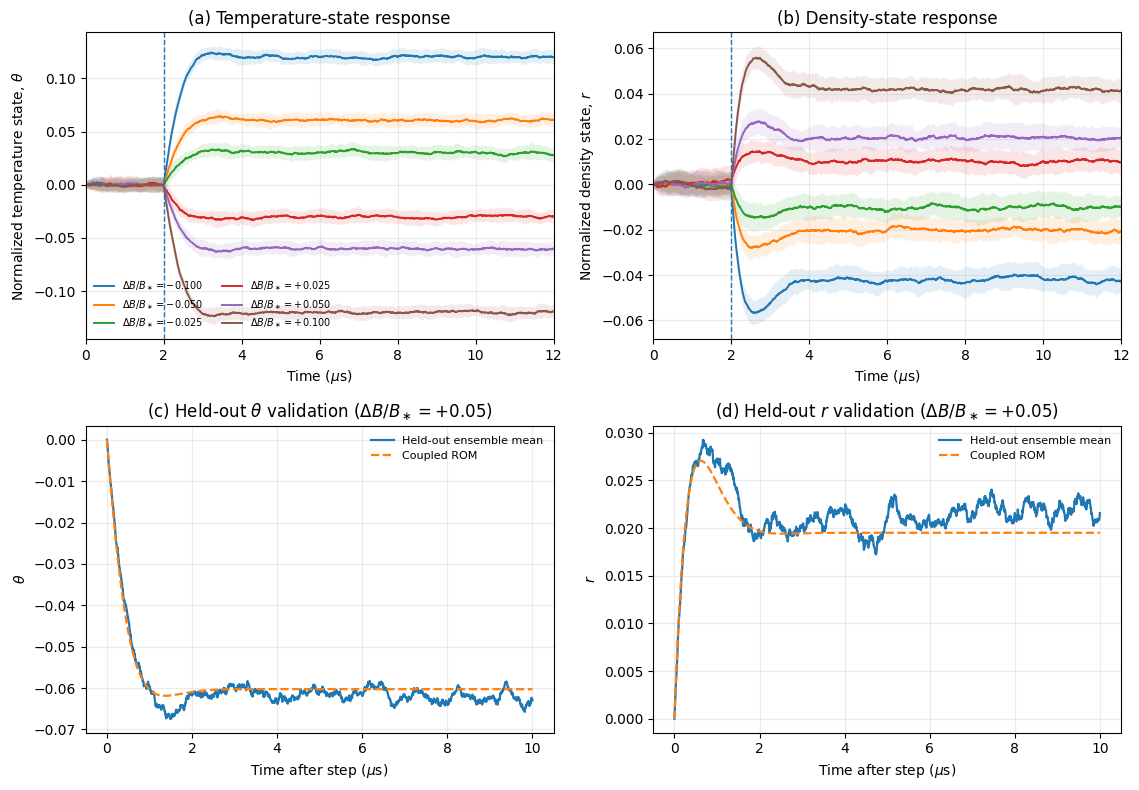

Saved:
  fig02_plasma_validation.pdf
  fig02_plasma_validation.png

Representative validation metrics:
amp = 0.05
train_rmse = [0.00088 0.00087]
test_rmse  = [0.00208 0.00199]
test_nrmse = [0.23532 0.68422]
modal      = {'eig1': np.complex128(-2252657.0311782053+1619358.7274746464j), 'eig2': np.complex128(-2252657.0311782053-1619358.7274746464j), 'trace': np.float64(-4505314.0623564115), 'det': np.float64(7696786388364.933), 'stable': True, 'complex_pair': True, 'wn_rad_s': np.float64(2774308.2720499774), 'fn_Hz': np.float64(441544.8751574887), 'zeta': np.float64(0.8119707005428363)}


In [119]:
# ============================================================
# MEA PUBLICATION FIGURE 2
# Plasma transient response and ROM validation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

amps = sorted(float(a) for a in STEP_AMPLITUDES)
representative_amp = 0.05

# Map Case 1B result by perturbation amplitude
result_by_amp = {
    float(item["amp"]): item
    for item in case1b_results
}

if representative_amp not in result_by_amp:
    raise RuntimeError(
        f"No Case 1B result found for amp={representative_amp}"
    )

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0)
)

ax_theta = axes[0, 0]
ax_r = axes[0, 1]
ax_theta_val = axes[1, 0]
ax_r_val = axes[1, 1]

# ------------------------------------------------------------
# Panels (a) and (b):
# stochastic ensemble responses across all six perturbations
# ------------------------------------------------------------

for amp in amps:

    runs = ensembles[amp]

    # Time vector is common across realizations
    t = runs[0]["t_s"].to_numpy()

    theta_runs = np.vstack([
        run["theta"].to_numpy()
        for run in runs
    ])

    r_runs = np.vstack([
        run["r"].to_numpy()
        for run in runs
    ])

    theta_mean = theta_runs.mean(axis=0)
    theta_std = theta_runs.std(axis=0, ddof=1)

    r_mean = r_runs.mean(axis=0)
    r_std = r_runs.std(axis=0, ddof=1)

    label = rf"$\Delta B/B_\ast={amp:+.3f}$"

    line_theta, = ax_theta.plot(
        t * 1e6,
        theta_mean,
        linewidth=1.4,
        label=label
    )

    ax_theta.fill_between(
        t * 1e6,
        theta_mean - theta_std,
        theta_mean + theta_std,
        alpha=0.12
    )

    line_r, = ax_r.plot(
        t * 1e6,
        r_mean,
        linewidth=1.4,
        label=label
    )

    ax_r.fill_between(
        t * 1e6,
        r_mean - r_std,
        r_mean + r_std,
        alpha=0.12
    )

# Applied field step at 2 us
for ax in (ax_theta, ax_r):
    ax.axvline(
        2.0,
        linestyle="--",
        linewidth=1.0
    )
    ax.grid(alpha=0.25)
    ax.set_xlim(0, 12)

ax_theta.set_title(
    "(a) Temperature-state response"
)
ax_theta.set_xlabel(
    "Time ($\\mu$s)"
)
ax_theta.set_ylabel(
    r"Normalized temperature state, $\theta$"
)

ax_r.set_title(
    "(b) Density-state response"
)
ax_r.set_xlabel(
    "Time ($\\mu$s)"
)
ax_r.set_ylabel(
    r"Normalized density state, $r$"
)

ax_theta.legend(
    fontsize=7,
    frameon=False,
    ncol=2
)

# ------------------------------------------------------------
# Panels (c) and (d):
# held-out ensemble mean vs retained coupled ROM
# ------------------------------------------------------------

rep = result_by_amp[representative_amp]

t_test = np.asarray(rep["t_test"])
x_test = np.asarray(rep["x_test"])
pred_test = np.asarray(rep["pred_test"])

ax_theta_val.plot(
    t_test * 1e6,
    x_test[:, 0],
    linewidth=1.6,
    label="Held-out ensemble mean"
)

ax_theta_val.plot(
    t_test * 1e6,
    pred_test[:, 0],
    linestyle="--",
    linewidth=1.6,
    label="Coupled ROM"
)

ax_theta_val.set_title(
    rf"(c) Held-out $\theta$ validation "
    rf"($\Delta B/B_\ast={representative_amp:+.2f}$)"
)

ax_theta_val.set_xlabel(
    "Time after step ($\\mu$s)"
)

ax_theta_val.set_ylabel(
    r"$\theta$"
)

ax_theta_val.grid(
    alpha=0.25
)

ax_theta_val.legend(
    fontsize=8,
    frameon=False
)

ax_r_val.plot(
    t_test * 1e6,
    x_test[:, 1],
    linewidth=1.6,
    label="Held-out ensemble mean"
)

ax_r_val.plot(
    t_test * 1e6,
    pred_test[:, 1],
    linestyle="--",
    linewidth=1.6,
    label="Coupled ROM"
)

ax_r_val.set_title(
    rf"(d) Held-out $r$ validation "
    rf"($\Delta B/B_\ast={representative_amp:+.2f}$)"
)

ax_r_val.set_xlabel(
    "Time after step ($\\mu$s)"
)

ax_r_val.set_ylabel(
    r"$r$"
)

ax_r_val.grid(
    alpha=0.25
)

ax_r_val.legend(
    fontsize=8,
    frameon=False
)

# ------------------------------------------------------------
# Layout and export
# ------------------------------------------------------------

plt.tight_layout()

fig.savefig(
    "fig02_plasma_validation.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "fig02_plasma_validation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("  fig02_plasma_validation.pdf")
print("  fig02_plasma_validation.png")

print("\nRepresentative validation metrics:")
print("amp =", representative_amp)
print("train_rmse =", rep["train_rmse"])
print("test_rmse  =", rep["test_rmse"])
print("test_nrmse =", rep["test_nrmse"])
print("modal      =", rep["modal"])

In [120]:
# ============================================================
# CASE 1E — REVIEWER-RESPONSE MODEL-SELECTION EXPERIMENT
# Finite-zero scalar second-order candidate
#
# Objective:
# Reassess the original scalar-model rejection using a general
# second-order SISO transfer function with one finite zero.
#
# Candidate ladder:
#   G1   : first-order scalar
#   G2   : original zero-free second-order scalar
#   G2z  : general second-order scalar with one finite zero
#   SS2  : retained coupled two-state state-space representation
#
# Important:
# - no change to the plasma surrogate
# - no change to stochastic realizations
# - no post hoc acceptance thresholds
# - existing Case 1A/1B evidence remains unchanged
# ============================================================

In [121]:
# ============================================================
# CASE 1E — Preflight
# Inspect existing Case 1 model-selection objects
# ============================================================

required_candidates = [
    "ensembles",
    "STEP_AMPLITUDES",
    "BASELINE",
    "SURROGATE",
    "SIM",
    "SEED",
    "case1b_results",
]

print("Core Case 1 objects:")
for name in required_candidates:
    print(f"{name:28s}: {name in globals()}")

print("\nLikely original Case 1A model-selection objects:")

keywords = (
    "fit",
    "first",
    "second",
    "scalar",
    "aic",
    "aicc",
    "rmse",
    "nrmse",
    "model",
    "candidate",
    "case1a",
    "train",
    "test",
    "predict",
)

matches = []

global_snapshot = list(globals().items())

for name, obj in global_snapshot:

    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):

        typename = type(obj).__name__

        if hasattr(obj, "shape"):
            detail = f"shape={obj.shape}"

        elif isinstance(obj, (list, tuple, dict)):
            detail = f"len={len(obj)}"

        else:
            detail = ""

        matches.append(
            (name, typename, detail)
        )

for name, typename, detail in sorted(matches):
    print(
        f"{name:40s} "
        f"{typename:18s} "
        f"{detail}"
    )

Core Case 1 objects:
ensembles                   : True
STEP_AMPLITUDES             : True
BASELINE                    : True
SURROGATE                   : True
SIM                         : True
SEED                        : True
case1b_results              : True

Likely original Case 1A model-selection objects:
aicc                                     function           
first_condition                          list               len=50
first_run                                DataFrame          shape=(2401, 7)
fit_models                               function           
fit_table                                DataFrame          shape=(12, 14)
median_nrmse_r                           float64            shape=()
median_nrmse_theta                       float64            shape=()
nrmse                                    function           
possible_fit_objects                     list               len=8
pred_test                                ndarray            shape=(2001, 2)
req

In [122]:
# ============================================================
# CASE 1E — Inspect original Case 1A fitting API and results
# ============================================================

import inspect

for fn_name in [
    "fit_models",
    "simulate_first_order",
    "simulate_second_order",
    "aicc",
    "summarize_candidate",
]:
    fn = globals()[fn_name]

    print("\n" + "=" * 72)
    print(fn_name)
    print("=" * 72)

    try:
        print("signature:", inspect.signature(fn))
    except Exception as exc:
        print("signature unavailable:", exc)

    try:
        src = inspect.getsource(fn)
        print(src[:5000])
    except Exception as exc:
        print("source unavailable:", exc)

print("\n" + "=" * 72)
print("fit_table")
print("=" * 72)
print("shape:", fit_table.shape)
print("columns:", list(fit_table.columns))
print(fit_table.head(12).to_string(index=False))


fit_models
signature: (amp, output)
def fit_models(
    amp,
    output
):

    (
        t,
        u,
        y_train,
        y_test
    ) = prepare_condition(
        amp,
        output
    )

    # ----------------------------------
    # First-order model
    # ----------------------------------

    def residual_first(p):

        K = p[0]

        tau = np.exp(
            p[1]
        )

        pred = (
            simulate_first_order(
                t,
                u,
                K,
                tau
            )
        )

        return (
            pred
            - y_train
        )

    fit1 = least_squares(
        residual_first,
        [
            1.0,
            np.log(
                0.5e-6
            )
        ],
        max_nfev=300
    )

    K1 = fit1.x[0]

    tau1 = np.exp(
        fit1.x[1]
    )

    pred1 = (
        simulate_first_order(
            t,
            u,
            K1,
            tau1
        )
    )

    # -----------

In [123]:
# ============================================================
# CASE 1E — Inspect original data preparation state
# ============================================================

print("y_train shape:", getattr(y_train, "shape", None))
print("y_test shape :", getattr(y_test, "shape", None))

print("\nOther likely preparation objects:")

prep_keywords = (
    "time",
    "train",
    "test",
    "ensemble",
    "mean",
    "condition",
    "prepare",
    "observable",
    "amp",
)

snapshot = list(globals().items())

for name, obj in sorted(snapshot):

    lname = name.lower()

    if (
        any(k in lname for k in prep_keywords)
        and not name.startswith("_")
        and name not in {"y_train", "y_test"}
    ):
        if hasattr(obj, "shape"):
            print(f"{name:36s} {type(obj).__name__:18s} shape={obj.shape}")
        elif isinstance(obj, (list, tuple, dict)):
            print(f"{name:36s} {type(obj).__name__:18s} len={len(obj)}")

y_train shape: (2001,)
y_test shape : (2001,)

Other likely preparation objects:
STEP_AMPLITUDES                      ndarray            shape=(6,)
amps                                 list               len=6
ensembles                            dict               len=6
first_condition                      list               len=50
mean                                 ndarray            shape=(2001,)
mean_noise                           ndarray            shape=(2001, 2)
pred_test                            ndarray            shape=(2001, 2)
r_mean                               ndarray            shape=(2401,)
result_by_amp                        dict               len=6
selected_amplitudes                  list               len=3
t_test                               ndarray            shape=(2001,)
theta_mean                           ndarray            shape=(2401,)
x_test                               ndarray            shape=(2001, 2)


In [124]:
# ============================================================
# CASE 1E — Freeze original preparation and acceptance criteria
# ============================================================

import inspect

print("=" * 72)
print("prepare_condition")
print("=" * 72)
print("signature:", inspect.signature(prepare_condition))
print(inspect.getsource(prepare_condition))

print("\n" + "=" * 72)
print("CRITERIA")
print("=" * 72)
print(CRITERIA)

print("\n" + "=" * 72)
print("bic")
print("=" * 72)
print("signature:", inspect.signature(bic))
print(inspect.getsource(bic))

prepare_condition
signature: (amp, output)
def prepare_condition(
    amp,
    output
):

    runs = ensembles[
        float(amp)
    ]

    n_train = SIM[
        "n_train"
    ]

    train = np.stack([
        run[output]
        .to_numpy()

        for run
        in runs[:n_train]
    ])

    test = np.stack([
        run[output]
        .to_numpy()

        for run
        in runs[n_train:]
    ])

    t_full = (
        runs[0]["t_s"]
        .to_numpy()
    )

    u_full = (
        runs[0]["u_B"]
        .to_numpy()
    )

    mask = (
        t_full
        >= SIM["t_step_s"]
    )

    t = (
        t_full[mask]
        -
        SIM["t_step_s"]
    )

    u = u_full[mask]

    y_train = (
        train[:, mask]
        .mean(axis=0)
    )

    y_test = (
        test[:, mask]
        .mean(axis=0)
    )

    # remove small stochastic
    # post-step offset

    y_train = (
        y_train
        - y_train[0]
    )

    y_test = (
        y_test
        - y_test[0]
    )



In [ ]:
# ============================================================
# CASE 1E — Finite-zero scalar second-order candidate
#
# Adds:
#
#       K wn^2 (1 + tau_z s)
# G2z = ---------------------
#       s^2 + 2 zeta wn s + wn^2
#
# Uses exactly the original:
# - prepare_condition()
# - train/test split
# - least_squares()
# - NRMSE
# - AICc
# - BIC
# - acceptance thresholds
#
# No surrogate parameters or original evidence are changed.
# ============================================================

import numpy as np
import pandas as pd

from scipy.optimize import least_squares
from scipy.signal import StateSpace, lsim


# ------------------------------------------------------------
# Finite-zero second-order simulator
# ------------------------------------------------------------

def simulate_second_order_zero(
    t,
    u,
    K,
    wn,
    zeta,
    tau_z
):
    """
    Transfer function:

              K * wn^2 * (1 + tau_z s)
    G(s) = --------------------------------
           s^2 + 2*zeta*wn*s + wn^2

    Strictly proper for finite tau_z.

    State-space realization:

        x1_dot = x2
        x2_dot = -wn^2 x1 - 2*zeta*wn x2 + u

        y = K*wn^2*x1 + K*wn^2*tau_z*x2

    which gives numerator:
        K*wn^2*tau_z*s + K*wn^2
    """

    A = np.array([
        [0.0, 1.0],
        [
            -wn**2,
            -2.0*zeta*wn
        ]
    ])

    B = np.array([
        [0.0],
        [1.0]
    ])

    C = np.array([
        [
            K*wn**2,
            K*wn**2*tau_z
        ]
    ])

    D = np.array([
        [0.0]
    ])

    sys = StateSpace(
        A,
        B,
        C,
        D
    )

    _, y, _ = lsim(
        sys,
        U=u,
        T=t
    )

    return (
        np.asarray(y)
        .reshape(-1)
    )


# ------------------------------------------------------------
# Fit one finite-zero candidate
# ------------------------------------------------------------

def fit_second_order_zero(
    amp,
    output
):

    (
        t,
        u,
        y_train,
        y_test
    ) = prepare_condition(
        amp,
        output
    )

    # Re-use original G2 result as the pole/gain initialisation.
    base = fit_table[
        np.isclose(
            fit_table["amp"],
            float(amp)
        )
        &
        (
            fit_table["output"]
            ==
            output
        )
    ]

    if len(base) != 1:
        raise RuntimeError(
            f"Expected one original G2 row for "
            f"amp={amp}, output={output}; "
            f"found {len(base)}"
        )

    base = base.iloc[0]

    K0 = float(
        base["K2"]
    )

    wn0 = float(
        base["wn2_rad_s"]
    )

    zeta0 = float(
        base["zeta2"]
    )

    # --------------------------------------------------------
    # tau_z is optimized in microseconds for numerical scaling.
    #
    # These are deterministic starting points.
    # tau_z = 0 reproduces the original zero-free G2 model.
    # --------------------------------------------------------

    tau_z_initial_us = [
        0.0,
        0.10,
        0.25,
        0.50,
        0.75,
        1.00,
        -0.10,
        -0.25,
        -0.50,
        -0.75,
        -1.00,
    ]

    candidate_fits = []

    def residual_zero(p):

        K = p[0]

        wn = np.exp(
            p[1]
        )

        zeta = np.exp(
            p[2]
        )

        tau_z = (
            p[3]
            *
            1e-6
        )

        pred = (
            simulate_second_order_zero(
                t,
                u,
                K,
                wn,
                zeta,
                tau_z
            )
        )

        return (
            pred
            -
            y_train
        )

    for tau0_us in tau_z_initial_us:

        try:

            fit = least_squares(
                residual_zero,
                [
                    K0,
                    np.log(wn0),
                    np.log(zeta0),
                    tau0_us
                ],
                max_nfev=1000
            )

            K = float(
                fit.x[0]
            )

            wn = float(
                np.exp(
                    fit.x[1]
                )
            )

            zeta = float(
                np.exp(
                    fit.x[2]
                )
            )

            tau_z_us = float(
                fit.x[3]
            )

            tau_z = (
                tau_z_us
                *
                1e-6
            )

            pred = (
                simulate_second_order_zero(
                    t,
                    u,
                    K,
                    wn,
                    zeta,
                    tau_z
                )
            )

            rss = float(
                np.sum(
                    (
                        y_train
                        -
                        pred
                    )**2
                )
            )

            candidate_fits.append({
                "fit": fit,
                "K": K,
                "wn": wn,
                "zeta": zeta,
                "tau_z_s": tau_z,
                "tau_z_us": tau_z_us,
                "pred": pred,
                "rss": rss
            })

        except Exception as exc:

            print(
                "Fit failure:",
                "amp =", amp,
                "output =", output,
                "tau0_us =", tau0_us,
                "error =", exc
            )

    if not candidate_fits:
        raise RuntimeError(
            f"No G2z fit succeeded for "
            f"amp={amp}, output={output}"
        )

    # Select minimum training RSS across deterministic starts
    best = min(
        candidate_fits,
        key=lambda x: x["rss"]
    )

    K = best["K"]
    wn = best["wn"]
    zeta = best["zeta"]
    tau_z = best["tau_z_s"]
    tau_z_us = best["tau_z_us"]
    pred = best["pred"]
    rss = best["rss"]

    # --------------------------------------------------------
    # Derived zero
    # --------------------------------------------------------

    if abs(tau_z) > 1e-18:

        zero_rad_s = (
            -1.0
            /
            tau_z
        )

        zero_Hz = (
            zero_rad_s
            /
            (2.0*np.pi)
        )

        zero_to_wn = (
            abs(zero_rad_s)
            /
            wn
        )

    else:

        zero_rad_s = np.inf
        zero_Hz = np.inf
        zero_to_wn = np.inf

    # --------------------------------------------------------
    # Metrics
    #
    # k = 4:
    # K, wn, zeta, tau_z
    # --------------------------------------------------------

    result = {

        "amp":
            float(amp),

        "output":
            output,

        "K2z":
            K,

        "wn2z_rad_s":
            wn,

        "fn2z_Hz":
            wn
            /
            (2.0*np.pi),

        "zeta2z":
            zeta,

        "tau_z_s":
            tau_z,

        "tau_z_us":
            tau_z_us,

        "zero_rad_s":
            zero_rad_s,

        "zero_Hz":
            zero_Hz,

        "abs_zero_over_wn":
            zero_to_wn,

        "test_nrmse_2z":
            nrmse(
                y_test,
                pred
            ),

        "AICc_2z":
            aicc(
                len(t),
                rss,
                4
            ),

        "BIC_2z":
            bic(
                len(t),
                rss,
                4
            ),

        "train_rss_2z":
            rss,

        "optimizer_success":
            bool(
                best["fit"].success
            ),

        "optimizer_nfev":
            int(
                best["fit"].nfev
            )
    }

    curves = {
        "t": t,
        "u": u,
        "y_train": y_train,
        "y_test": y_test,
        "pred_2z": pred
    }

    return (
        result,
        curves
    )


# ------------------------------------------------------------
# Run all 12 Case 1E fits
# ------------------------------------------------------------

case1e_rows = []
case1e_curves = {}

for output in [
    "theta",
    "r"
]:

    for amp in STEP_AMPLITUDES:

        result, curves = (
            fit_second_order_zero(
                float(amp),
                output
            )
        )

        case1e_rows.append(
            result
        )

        case1e_curves[
            (
                output,
                float(amp)
            )
        ] = curves


case1e_fit_table = (
    pd.DataFrame(
        case1e_rows
    )
    .sort_values(
        [
            "output",
            "amp"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Merge original G1/G2 evidence for direct comparison
# ------------------------------------------------------------

case1e_comparison = (
    fit_table.merge(
        case1e_fit_table,
        on=[
            "amp",
            "output"
        ],
        how="inner"
    )
)


# ------------------------------------------------------------
# Additional direct comparison metrics
# ------------------------------------------------------------

case1e_comparison[
    "improvement_2_vs_1"
] = (
    1.0
    -
    case1e_comparison[
        "test_nrmse_2"
    ]
    /
    case1e_comparison[
        "test_nrmse_1"
    ]
)


case1e_comparison[
    "improvement_2z_vs_1"
] = (
    1.0
    -
    case1e_comparison[
        "test_nrmse_2z"
    ]
    /
    case1e_comparison[
        "test_nrmse_1"
    ]
)


case1e_comparison[
    "improvement_2z_vs_2"
] = (
    1.0
    -
    case1e_comparison[
        "test_nrmse_2z"
    ]
    /
    case1e_comparison[
        "test_nrmse_2"
    ]
)


case1e_comparison[
    "delta_AICc_2_vs_1"
] = (
    case1e_comparison[
        "AICc_1"
    ]
    -
    case1e_comparison[
        "AICc_2"
    ]
)


case1e_comparison[
    "delta_AICc_2z_vs_1"
] = (
    case1e_comparison[
        "AICc_1"
    ]
    -
    case1e_comparison[
        "AICc_2z"
    ]
)


case1e_comparison[
    "delta_AICc_2z_vs_2"
] = (
    case1e_comparison[
        "AICc_2"
    ]
    -
    case1e_comparison[
        "AICc_2z"
    ]
)


# ------------------------------------------------------------
# Display compact result
# ------------------------------------------------------------

display_columns = [
    "amp",
    "output",

    "test_nrmse_1",
    "test_nrmse_2",
    "test_nrmse_2z",

    "AICc_1",
    "AICc_2",
    "AICc_2z",

    "fn2z_Hz",
    "zeta2z",
    "zero_rad_s",
    "abs_zero_over_wn"
]

print(
    case1e_comparison[
        display_columns
    ].to_string(
        index=False
    )
)

   amp output  test_nrmse_1  test_nrmse_2  test_nrmse_2z        AICc_1        AICc_2       AICc_2z       fn2z_Hz   zeta2z    zero_rad_s  abs_zero_over_wn
-0.100  theta      0.315855      0.300988       0.284866 -24016.132244 -25079.289320 -26931.299271 484119.208850 0.792714 -4.374219e+06          1.438031
-0.050  theta      0.246441      0.233484       0.202965 -25985.985980 -26591.117623 -27871.450899 413718.241843 0.796292 -2.996561e+06          1.152759
-0.025  theta      0.744966      0.727496       0.703852 -26593.917583 -26798.745971 -27086.062491 468490.235529 0.768230 -5.019088e+06          1.705078
 0.025  theta      0.574108      0.553964       0.595677 -26455.425715 -26620.290945 -27852.596325 268510.257995 0.870668 -1.143163e+06          0.677590
 0.050  theta      0.279251      0.266499       0.242822 -26773.368977 -27295.998471 -28240.298753 495695.736772 0.825940 -4.449852e+06          1.428731
 0.100  theta      0.159771      0.140783       0.143428 -24088.747210 -2521

In [125]:
# ============================================================
# CASE 1E — Pre-specified decision analysis
# ============================================================

def summarize_g2z_candidate(
    output
):

    d = (
        case1e_comparison[
            case1e_comparison[
                "output"
            ]
            ==
            output
        ]
        .copy()
    )

    cv_wn = (
        d["wn2z_rad_s"].std()
        /
        d["wn2z_rad_s"].mean()
    )

    cv_zeta = (
        d["zeta2z"].std()
        /
        d["zeta2z"].mean()
    )

    summary = {

        "output":
            output,

        # Same original decision comparison:
        # finite-zero G2z relative to G1
        "median_holdout_improvement_vs_G1":
            float(
                np.median(
                    d[
                        "improvement_2z_vs_1"
                    ]
                )
            ),

        "median_delta_AICc_vs_G1":
            float(
                np.median(
                    d[
                        "delta_AICc_2z_vs_1"
                    ]
                )
            ),

        "cv_wn":
            float(
                cv_wn
            ),

        "cv_zeta":
            float(
                cv_zeta
            ),

        # Additional diagnostic comparison
        # against original zero-free G2
        "median_holdout_improvement_vs_G2":
            float(
                np.median(
                    d[
                        "improvement_2z_vs_2"
                    ]
                )
            ),

        "median_delta_AICc_vs_G2":
            float(
                np.median(
                    d[
                        "delta_AICc_2z_vs_2"
                    ]
                )
            ),

        "median_abs_zero_over_wn":
            float(
                np.median(
                    d[
                        "abs_zero_over_wn"
                    ]
                )
            )
    }

    accepted = (

        summary[
            "median_holdout_improvement_vs_G1"
        ]
        >=
        CRITERIA[
            "min_improvement"
        ]

        and

        summary[
            "median_delta_AICc_vs_G1"
        ]
        >=
        CRITERIA[
            "min_delta_aicc"
        ]

        and

        summary[
            "cv_wn"
        ]
        <=
        CRITERIA[
            "max_cv_wn"
        ]

        and

        summary[
            "cv_zeta"
        ]
        <=
        CRITERIA[
            "max_cv_zeta"
        ]
    )

    summary[
        "accepted_under_original_criteria"
    ] = bool(
        accepted
    )

    return summary


case1e_summary = pd.DataFrame([
    summarize_g2z_candidate(
        "theta"
    ),
    summarize_g2z_candidate(
        "r"
    )
])


print(
    "=" * 72
)
print(
    "CASE 1E — FINITE-ZERO MODEL-SELECTION SUMMARY"
)
print(
    "=" * 72
)

print(
    case1e_summary.to_string(
        index=False
    )
)

print(
    "\nOriginal criteria:"
)

for key, value in CRITERIA.items():
    print(
        f"  {key}: {value}"
    )


print(
    "\nInterpretation rule:"
)

for _, row in case1e_summary.iterrows():

    output = row[
        "output"
    ]

    accepted = bool(
        row[
            "accepted_under_original_criteria"
        ]
    )

    if accepted:

        print(
            f"  {output}: G2z PASSES the original "
            f"candidate acceptance criteria."
        )

        print(
            "    -> Do NOT claim that scalar "
            "second-order input-output dynamics "
            "are rejected for this observable."
        )

    else:

        print(
            f"  {output}: G2z FAILS the original "
            f"candidate acceptance criteria."
        )

        print(
            "    -> The finite-zero extension does "
            "not rescue the scalar candidate under "
            "the pre-specified criteria."
        )

NameError: name 'case1e_comparison' is not defined

In [ ]:
# ============================================================
# CASE 1F — PRE-FLIGHT
# Inspect existing coupled state-space identification machinery
# ============================================================

import inspect

candidate_names = [
    "prepare_state_condition",
    "smooth_and_differentiate",
    "fit_state_space",
    "identify_state_space",
    "predict_state_space",
    "simulate_state_space",
    "modal_from_A",
]

for name in candidate_names:

    if name not in globals():
        continue

    obj = globals()[name]

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    try:
        print("signature:", inspect.signature(obj))
    except Exception as exc:
        print("signature unavailable:", exc)

    try:
        print(inspect.getsource(obj)[:6000])
    except Exception as exc:
        print("source unavailable:", exc)


print("\n" + "=" * 72)
print("CASE 1B RESULT STRUCTURE")
print("=" * 72)

print("case1b_results type:", type(case1b_results))
print("number of entries:", len(case1b_results))

for i, entry in enumerate(case1b_results[:2]):
    print(f"\nentry {i}")
    print("keys:", list(entry.keys()))

    for key, value in entry.items():
        if hasattr(value, "shape"):
            print(f"  {key:24s} shape={value.shape}")
        elif isinstance(value, dict):
            print(f"  {key:24s} dict keys={list(value.keys())}")
        else:
            print(f"  {key:24s} {value}")


prepare_state_condition
signature: (amp, subset='train')
def prepare_state_condition(
    amp,
    subset="train"
):

    runs = ensembles[
        float(amp)
    ]

    if subset == "train":

        selected = runs[
            :SIM["n_train"]
        ]

    elif subset == "test":

        selected = runs[
            SIM["n_train"]:
        ]

    else:

        raise ValueError(
            "subset must be "
            "'train' or 'test'"
        )

    t_full = (
        selected[0]["t_s"]
        .to_numpy()
    )

    mask = (
        t_full
        >= SIM["t_step_s"]
    )

    t = (
        t_full[mask]
        -
        SIM["t_step_s"]
    )

    theta = np.stack([
        run["theta"]
        .to_numpy()[mask]

        for run
        in selected
    ]).mean(axis=0)

    r = np.stack([
        run["r"]
        .to_numpy()[mask]

        for run
        in selected
    ]).mean(axis=0)

    u = (
        selected[0]["u_B"]
        .to_numpy()[mask]
    )

    # remove tiny s

In [ ]:
# ============================================================
# CASE 1F — Inspect state preparation / regression state
# ============================================================

keywords = (
    "state",
    "smooth",
    "deriv",
    "design",
    "regress",
    "matrix",
    "train",
    "pred",
    "modal",
    "case1b",
)

snapshot = list(globals().items())

for name, obj in sorted(snapshot):

    lname = name.lower()

    if (
        any(k in lname for k in keywords)
        and not name.startswith("_")
    ):

        if hasattr(obj, "shape"):
            print(
                f"{name:40s} "
                f"{type(obj).__name__:18s} "
                f"shape={obj.shape}"
            )

        elif isinstance(obj, (list, tuple, dict)):
            print(
                f"{name:40s} "
                f"{type(obj).__name__:18s} "
                f"len={len(obj)}"
            )

CASE1B_CRITERIA                          dict               len=4
H_MODAL                                  ndarray            shape=(601,)
case1b_export                            dict               len=4
case1b_results                           list               len=6
case1b_rows                              list               len=6
case1b_table                             DataFrame          shape=(6, 18)
case1d_modal                             DataFrame          shape=(6, 10)
case1f_prediction_check                  DataFrame          shape=(6, 3)
modal                                    dict               len=8
modal0                                   dict               len=10
modal_demo                               dict               len=9
phase_modal                              ndarray            shape=(601,)
pred                                     ndarray            shape=(2001,)
pred1                                    ndarray            shape=(2001,)
pred2                 

In [ ]:
# ============================================================
# CASE 1F — Predictor consistency check
#
# Confirm that a direct StateSpace/lsim predictor reproduces
# the original Case 1B stored predictions before LOPO begins.
# ============================================================

import numpy as np
import pandas as pd

from scipy.signal import StateSpace, lsim


def predict_state_space_AB(
    t,
    u,
    A,
    B,
    x0=None
):
    """
    Predict x(t) for

        xdot = A x + B u

    with full state output y = x.
    """

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float).reshape(2, 1)

    C = np.eye(2)
    D = np.zeros((2, 1))

    if x0 is None:
        x0 = np.zeros(2)

    sys = StateSpace(
        A,
        B,
        C,
        D
    )

    _, y, _ = lsim(
        sys,
        U=np.asarray(u),
        T=np.asarray(t),
        X0=np.asarray(x0)
    )

    return np.asarray(y)


# ------------------------------------------------------------
# Verify against every original Case 1B stored prediction
# ------------------------------------------------------------

consistency_rows = []

for result in case1b_results:

    amp = float(result["amp"])

    pred_rebuilt = predict_state_space_AB(
        result["t_test"],
        prepare_state_condition(
            amp,
            subset="test"
        )[2],
        result["A"],
        result["B"],
        x0=np.zeros(2)
    )

    pred_stored = np.asarray(
        result["pred_test"]
    )

    max_abs_diff = np.max(
        np.abs(
            pred_rebuilt
            -
            pred_stored
        )
    )

    rms_diff = np.sqrt(
        np.mean(
            (
                pred_rebuilt
                -
                pred_stored
            )**2
        )
    )

    consistency_rows.append({
        "amp":
            amp,
        "max_abs_prediction_difference":
            max_abs_diff,
        "rms_prediction_difference":
            rms_diff
    })


case1f_prediction_check = pd.DataFrame(
    consistency_rows
)

print(
    case1f_prediction_check.to_string(
        index=False
    )
)

print(
    "\nOverall maximum absolute difference:",
    case1f_prediction_check[
        "max_abs_prediction_difference"
    ].max()
)

   amp  max_abs_prediction_difference  rms_prediction_difference
-0.100                            0.0                        0.0
-0.050                            0.0                        0.0
-0.025                            0.0                        0.0
 0.025                            0.0                        0.0
 0.050                            0.0                        0.0
 0.100                            0.0                        0.0

Overall maximum absolute difference: 0.0


In [ ]:
# ============================================================
# CASE 1F — Descriptive summary
#
# No new pass/fail threshold is imposed.
# ============================================================

print(
    "=" * 88
)

print(
    "CASE 1F — DESCRIPTIVE SUMMARY"
)

print(
    "=" * 88
)


print(
    "\nPrediction NRMSE:"
)

print(
    "theta median =",
    case1f_table[
        "test_nrmse_theta"
    ].median()
)

print(
    "theta max    =",
    case1f_table[
        "test_nrmse_theta"
    ].max()
)

print(
    "r median     =",
    case1f_table[
        "test_nrmse_r"
    ].median()
)

print(
    "r max        =",
    case1f_table[
        "test_nrmse_r"
    ].max()
)


print(
    "\nNoise-floor-normalized error:"
)

print(
    "theta median =",
    case1f_table[
        "E_NF_theta"
    ].median()
)

print(
    "theta max    =",
    case1f_table[
        "E_NF_theta"
    ].max()
)

print(
    "r median     =",
    case1f_table[
        "E_NF_r"
    ].median()
)

print(
    "r max        =",
    case1f_table[
        "E_NF_r"
    ].max()
)


print(
    "\nLOPO modal estimates:"
)

print(
    "fn mean ± SD =",
    case1f_table[
        "fn_Hz"
    ].mean(),
    "±",
    case1f_table[
        "fn_Hz"
    ].std(ddof=1),
    "Hz"
)

print(
    "zeta mean ± SD =",
    case1f_table[
        "zeta"
    ].mean(),
    "±",
    case1f_table[
        "zeta"
    ].std(ddof=1)
)


print(
    "\nTopology:"
)

print(
    "stable folds =",
    int(
        case1f_table[
            "stable"
        ].sum()
    ),
    "/",
    len(
        case1f_table
    )
)

print(
    "complex-pair folds =",
    int(
        case1f_table[
            "complex_pair"
        ].sum()
    ),
    "/",
    len(
        case1f_table
    )
)


print(
    "\nInterpolation folds:"
)

print(
    case1f_table[
        case1f_table[
            "fold_type"
        ]
        ==
        "interpolation"
    ][
        [
            "held_out_amp",
            "test_nrmse_theta",
            "test_nrmse_r",
            "E_NF_theta",
            "E_NF_r"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nEdge extrapolation folds:"
)

print(
    case1f_table[
        case1f_table[
            "fold_type"
        ]
        ==
        "edge extrapolation"
    ][
        [
            "held_out_amp",
            "test_nrmse_theta",
            "test_nrmse_r",
            "E_NF_theta",
            "E_NF_r"
        ]
    ].to_string(
        index=False
    )
)

CASE 1F — DESCRIPTIVE SUMMARY

Prediction NRMSE:
theta median = 0.30902444174603994
theta max    = 0.5666813708928313
r median     = 0.7117287612223626
r max        = 1.587287557578961

Noise-floor-normalized error:
theta median = 0.3032605311701778
theta max    = 0.42326287071510355
r median     = 0.3492295224664996
r max        = 0.664989933510842

LOPO modal estimates:
fn mean ± SD = 421630.2715989291 ± 11902.795880074973 Hz
zeta mean ± SD = 0.8102390410272554 ± 0.005959151904254395

Topology:
stable folds = 6 / 6
complex-pair folds = 6 / 6

Interpolation folds:
 held_out_amp  test_nrmse_theta  test_nrmse_r  E_NF_theta   E_NF_r
       -0.050          0.343799      0.375321    0.347960 0.171032
       -0.025          0.555168      1.086420    0.319845 0.374108
        0.025          0.566681      1.587288    0.193419 0.340078
        0.050          0.274250      0.431569    0.286676 0.195788

Edge extrapolation folds:
 held_out_amp  test_nrmse_theta  test_nrmse_r  E_NF_theta   E_NF_r

In [ ]:
# ============================================================
# CASE 1F — SIX-FOLD LEAVE-ONE-PERTURBATION-OUT
# PREDICTIVE VERIFICATION
#
# For each held-out magnetic perturbation:
#
#   - use ONLY the original 35 training realizations
#     from the remaining five perturbation conditions;
#
#   - preprocess each condition independently using the
#     original Savitzky-Golay procedure;
#
#   - concatenate the five regression blocks;
#
#   - estimate ONE common A,B model;
#
#   - predict the held-out condition;
#
#   - evaluate against its original 15-realization
#     held-out test mean.
#
# No new acceptance threshold is introduced.
# ============================================================

import numpy as np
import pandas as pd


LOPO_AMPLITUDES = np.asarray(
    STEP_AMPLITUDES,
    dtype=float
)


# ------------------------------------------------------------
# Common multi-condition identification
# ------------------------------------------------------------

def identify_common_state_space(
    training_amplitudes,
    window_length=101,
    polyorder=3
):
    """
    Estimate one common A,B model from multiple perturbation
    conditions using the original Case 1B derivative-regression
    structure.

    Each trajectory is smoothed/differentiated independently.
    Regression blocks are concatenated only afterwards.
    """

    Z_blocks = []
    dx_blocks = []

    condition_info = []

    for amp in training_amplitudes:

        (
            t,
            x,
            u
        ) = prepare_state_condition(
            float(amp),
            subset="train"
        )

        (
            xs,
            dx
        ) = smooth_and_differentiate(
            t,
            x,
            window_length=window_length,
            polyorder=polyorder
        )

        Z = np.column_stack([
            xs,
            u
        ])

        Z_blocks.append(
            Z
        )

        dx_blocks.append(
            dx
        )

        condition_info.append({
            "amp":
                float(amp),
            "n_samples":
                len(t)
        })

    Z_all = np.vstack(
        Z_blocks
    )

    dx_all = np.vstack(
        dx_blocks
    )

    # Same least-squares estimator as original Case 1B
    M, residuals, rank, svals = np.linalg.lstsq(
        Z_all,
        dx_all,
        rcond=None
    )

    A = M[:2, :].T

    B = (
        M[2, :]
        .reshape(2, 1)
    )

    dx_pred = Z_all @ M

    derivative_rmse = np.sqrt(
        np.mean(
            (
                dx_all
                -
                dx_pred
            )**2,
            axis=0
        )
    )

    return {
        "A":
            A,

        "B":
            B,

        "M":
            M,

        "rank":
            int(rank),

        "singular_values":
            svals,

        "derivative_rmse":
            derivative_rmse,

        "n_total_samples":
            int(
                Z_all.shape[0]
            ),

        "training_conditions":
            condition_info
    }


# ------------------------------------------------------------
# Modal extraction from common A matrix
# ------------------------------------------------------------

def modal_from_A_case1f(
    A
):
    """
    Extract the same modal quantities used in Case 1B.
    """

    eigvals = np.linalg.eigvals(
        np.asarray(A)
    )

    # Stable if every real part is negative
    stable = bool(
        np.all(
            np.real(eigvals)
            <
            0.0
        )
    )

    complex_pair = bool(
        len(eigvals) == 2
        and
        np.all(
            np.abs(
                np.imag(eigvals)
            )
            >
            0.0
        )
    )

    # Sort for reproducibility:
    # positive imaginary member first
    eigvals = sorted(
        eigvals,
        key=lambda z:
            -np.imag(z)
    )

    eig1 = eigvals[0]
    eig2 = eigvals[1]

    if complex_pair:

        sigma = (
            -np.real(eig1)
        )

        wd = abs(
            np.imag(eig1)
        )

        wn = np.sqrt(
            sigma**2
            +
            wd**2
        )

        zeta = (
            sigma
            /
            wn
        )

        fn_Hz = (
            wn
            /
            (2.0*np.pi)
        )

        fd_Hz = (
            wd
            /
            (2.0*np.pi)
        )

    else:

        wn = np.nan
        zeta = np.nan
        fn_Hz = np.nan
        fd_Hz = np.nan

    return {
        "eig1":
            eig1,

        "eig2":
            eig2,

        "stable":
            stable,

        "complex_pair":
            complex_pair,

        "wn_rad_s":
            float(wn),

        "fn_Hz":
            float(fn_Hz),

        "fd_Hz":
            float(fd_Hz),

        "zeta":
            float(zeta)
    }


# ------------------------------------------------------------
# Run six LOPO folds
# ------------------------------------------------------------

case1f_rows = []
case1f_models = {}
case1f_curves = {}


for held_out_amp in LOPO_AMPLITUDES:

    training_amps = [
        float(a)

        for a in LOPO_AMPLITUDES

        if not np.isclose(
            a,
            held_out_amp
        )
    ]

    # --------------------------------------------------------
    # Identify ONE common model using five conditions
    # --------------------------------------------------------

    common = identify_common_state_space(
        training_amps,
        window_length=101,
        polyorder=3
    )

    A = common["A"]
    B = common["B"]

    modal = modal_from_A_case1f(
        A
    )

    # --------------------------------------------------------
    # Held-out TEST data only
    # --------------------------------------------------------

    (
        t_test,
        x_test,
        u_test
    ) = prepare_state_condition(
        float(held_out_amp),
        subset="test"
    )

    # No held-out trajectory enters identification.
    pred_test = predict_state_space_AB(
        t_test,
        u_test,
        A,
        B,
        x0=np.zeros(2)
    )

    # --------------------------------------------------------
    # Prediction metrics
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            (
                x_test
                -
                pred_test
            )**2,
            axis=0
        )
    )

    test_nrmse = np.array([
        nrmse(
            x_test[:, j],
            pred_test[:, j]
        )

        for j in range(2)
    ])

    # --------------------------------------------------------
    # Stochastic-spread benchmark for held-out condition
    #
    # Compute pointwise SD across the ORIGINAL 15 test
    # realizations, after exactly the same post-step offset
    # treatment as prepare_state_condition().
    # --------------------------------------------------------

    runs = ensembles[
        float(held_out_amp)
    ][
        SIM["n_train"]:
    ]

    t_full = (
        runs[0]["t_s"]
        .to_numpy()
    )

    mask = (
        t_full
        >=
        SIM["t_step_s"]
    )

    theta_runs = np.stack([
        run["theta"]
        .to_numpy()[mask]

        for run in runs
    ])

    r_runs = np.stack([
        run["r"]
        .to_numpy()[mask]

        for run in runs
    ])

    # Apply same per-realization t=0 offset removal
    theta_runs = (
        theta_runs
        -
        theta_runs[:, [0]]
    )

    r_runs = (
        r_runs
        -
        r_runs[:, [0]]
    )

    theta_sigma = np.std(
        theta_runs,
        axis=0,
        ddof=1
    )

    r_sigma = np.std(
        r_runs,
        axis=0,
        ddof=1
    )

    # RMS stochastic spread over time
    sigma_theta_rms = np.sqrt(
        np.mean(
            theta_sigma**2
        )
    )

    sigma_r_rms = np.sqrt(
        np.mean(
            r_sigma**2
        )
    )

    E_NF_theta = (
        rmse[0]
        /
        sigma_theta_rms
        if sigma_theta_rms > 0
        else np.nan
    )

    E_NF_r = (
        rmse[1]
        /
        sigma_r_rms
        if sigma_r_rms > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Interpolation / edge extrapolation classification
    # --------------------------------------------------------

    if np.isclose(
        held_out_amp,
        LOPO_AMPLITUDES.min()
    ) or np.isclose(
        held_out_amp,
        LOPO_AMPLITUDES.max()
    ):

        fold_type = (
            "edge extrapolation"
        )

    else:

        fold_type = (
            "interpolation"
        )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    case1f_rows.append({

        "held_out_amp":
            float(
                held_out_amp
            ),

        "fold_type":
            fold_type,

        "n_training_conditions":
            len(
                training_amps
            ),

        "training_amps":
            tuple(
                training_amps
            ),

        "rank":
            common["rank"],

        "test_rmse_theta":
            float(
                rmse[0]
            ),

        "test_rmse_r":
            float(
                rmse[1]
            ),

        "test_nrmse_theta":
            float(
                test_nrmse[0]
            ),

        "test_nrmse_r":
            float(
                test_nrmse[1]
            ),

        "E_NF_theta":
            float(
                E_NF_theta
            ),

        "E_NF_r":
            float(
                E_NF_r
            ),

        "fn_Hz":
            modal["fn_Hz"],

        "fd_Hz":
            modal["fd_Hz"],

        "zeta":
            modal["zeta"],

        "stable":
            modal["stable"],

        "complex_pair":
            modal["complex_pair"]
    })


    case1f_models[
        float(
            held_out_amp
        )
    ] = {

        "A":
            A.copy(),

        "B":
            B.copy(),

        "modal":
            modal,

        "training_amps":
            training_amps,

        "derivative_rmse":
            common[
                "derivative_rmse"
            ],

        "singular_values":
            common[
                "singular_values"
            ]
    }


    case1f_curves[
        float(
            held_out_amp
        )
    ] = {

        "t":
            t_test.copy(),

        "u":
            u_test.copy(),

        "x_test":
            x_test.copy(),

        "pred_test":
            pred_test.copy()
    }


case1f_table = (
    pd.DataFrame(
        case1f_rows
    )
    .sort_values(
        "held_out_amp"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_cols = [
    "held_out_amp",
    "fold_type",

    "test_nrmse_theta",
    "test_nrmse_r",

    "E_NF_theta",
    "E_NF_r",

    "fn_Hz",
    "zeta",

    "stable",
    "complex_pair"
]


print(
    "=" * 88
)

print(
    "CASE 1F — SIX-FOLD LEAVE-ONE-PERTURBATION-OUT RESULTS"
)

print(
    "=" * 88
)

print(
    case1f_table[
        display_cols
    ].to_string(
        index=False
    )
)

CASE 1F — SIX-FOLD LEAVE-ONE-PERTURBATION-OUT RESULTS
 held_out_amp          fold_type  test_nrmse_theta  test_nrmse_r  E_NF_theta   E_NF_r         fn_Hz     zeta  stable  complex_pair
       -0.100 edge extrapolation          0.224727      0.531294    0.423263 0.358381 402832.155014 0.814009    True          True
       -0.050      interpolation          0.343799      0.375321    0.347960 0.171032 422360.045362 0.804806    True          True
       -0.025      interpolation          0.555168      1.086420    0.319845 0.374108 422920.205717 0.812112    True          True
        0.025      interpolation          0.566681      1.587288    0.193419 0.340078 437910.645884 0.807407    True          True
        0.050      interpolation          0.274250      0.431569    0.286676 0.195788 428499.049223 0.803841    True          True
        0.100 edge extrapolation          0.122582      0.892163    0.236948 0.664990 415259.528394 0.819259    True          True


In [74]:
# ============================================================
# CASE 1G — PREFLIGHT
# Inspect exact surrogate parameterization
# ============================================================

print("=" * 72)
print("SURROGATE")
print("=" * 72)

for key, value in SURROGATE.items():
    print(f"{key:24s}: {value}")

print("\n" + "=" * 72)
print("SIM")
print("=" * 72)

for key, value in SIM.items():
    print(f"{key:24s}: {value}")

SURROGATE
tau_T_s                 : 3.5e-07
tau_n_s                 : 6e-07
a                       : 0.75
b                       : 0.9
c                       : 0.9
d                       : 1.5
gamma_T                 : 0.8
gamma_n                 : 0.5
sigma_T                 : 15.0
sigma_n                 : 10.0

SIM
dt_s                    : 5e-09
t_end_s                 : 1.2e-05
t_step_s                : 2e-06
n_realizations          : 50
n_train                 : 35


In [75]:
# ============================================================
# CASE 1G — KNOWN-LINEARIZATION RECOVERY AUDIT
#
# Compare:
#   1. exact nominal surrogate linearization;
#   2. six original per-condition Case 1B identifications;
#   3. six five-condition Case 1F LOPO common models.
#
# Also derive exact plasma transfer-function zeros and DC gains.
#
# Interpretation:
# This is an identification/recovery benchmark against known
# generating dynamics, not physical plasma validation.
# ============================================================

import numpy as np
import pandas as pd

from scipy.signal import ss2tf


# ------------------------------------------------------------
# Exact surrogate parameters
# ------------------------------------------------------------

tau_T = float(SURROGATE["tau_T_s"])
tau_n = float(SURROGATE["tau_n_s"])

a = float(SURROGATE["a"])
b = float(SURROGATE["b"])
c = float(SURROGATE["c"])
d = float(SURROGATE["d"])


# ------------------------------------------------------------
# Exact nominal Jacobian and input matrix
# ------------------------------------------------------------

A0 = np.array([
    [
        -1.0 / tau_T,
        -a / tau_T
    ],
    [
        c / tau_n,
        -1.0 / tau_n
    ]
], dtype=float)

B0 = np.array([
    [
        -b / tau_T
    ],
    [
        d / tau_n
    ]
], dtype=float)


print("=" * 80)
print("CASE 1G — EXACT NOMINAL LINEARIZATION")
print("=" * 80)

print("\nA0 =")
print(A0)

print("\nB0 =")
print(B0)


# ------------------------------------------------------------
# Modal extraction helper
# ------------------------------------------------------------

def modal_quantities_from_A(A):

    eigvals = np.linalg.eigvals(
        np.asarray(A, dtype=float)
    )

    # Choose positive-imaginary member if complex
    eig_sorted = sorted(
        eigvals,
        key=lambda z: -np.imag(z)
    )

    eig1 = eig_sorted[0]
    eig2 = eig_sorted[1]

    stable = bool(
        np.all(
            np.real(eigvals) < 0.0
        )
    )

    complex_pair = bool(
        np.all(
            np.abs(
                np.imag(eigvals)
            ) > 0.0
        )
    )

    if complex_pair:

        sigma = float(
            -np.real(eig1)
        )

        wd = float(
            abs(
                np.imag(eig1)
            )
        )

        wn = float(
            np.sqrt(
                sigma**2
                +
                wd**2
            )
        )

        zeta = float(
            sigma / wn
        )

        fn = float(
            wn
            /
            (2.0*np.pi)
        )

        fd = float(
            wd
            /
            (2.0*np.pi)
        )

    else:

        sigma = np.nan
        wd = np.nan
        wn = np.nan
        zeta = np.nan
        fn = np.nan
        fd = np.nan

    return {
        "eig1": eig1,
        "eig2": eig2,
        "stable": stable,
        "complex_pair": complex_pair,
        "sigma_rad_s": sigma,
        "wd_rad_s": wd,
        "wn_rad_s": wn,
        "fn_Hz": fn,
        "fd_Hz": fd,
        "zeta": zeta
    }


modal0 = modal_quantities_from_A(
    A0
)


print("\nExact nominal eigenstructure:")
for key, value in modal0.items():
    print(f"{key:18s}: {value}")


# ------------------------------------------------------------
# Exact transfer functions for theta and r
#
# xdot = A0 x + B0 u
# y    = C x
# ------------------------------------------------------------

C_theta = np.array([
    [1.0, 0.0]
])

C_r = np.array([
    [0.0, 1.0]
])

D0 = np.array([
    [0.0]
])


def transfer_function_properties(
    A,
    B,
    C,
    D
):

    num, den = ss2tf(
        A,
        B,
        C,
        D
    )

    num = np.asarray(
        num[0],
        dtype=float
    )

    den = np.asarray(
        den,
        dtype=float
    )

    # Remove leading numerical zeros
    tol = (
        1e-12
        *
        max(
            1.0,
            np.max(
                np.abs(num)
            )
        )
    )

    nz = np.where(
        np.abs(num) > tol
    )[0]

    if len(nz) > 0:
        num_trim = num[
            nz[0]:
        ]
    else:
        num_trim = np.array(
            [0.0]
        )

    zeros = (
        np.roots(
            num_trim
        )
        if len(num_trim) > 1
        else np.array([])
    )

    poles = np.roots(
        den
    )

    dc_gain = (
        num_trim[-1]
        /
        den[-1]
        if den[-1] != 0
        else np.nan
    )

    relative_degree = (
        len(den)
        -
        len(num_trim)
    )

    return {
        "numerator": num_trim,
        "denominator": den,
        "zeros": zeros,
        "poles": poles,
        "dc_gain": float(dc_gain),
        "relative_degree": int(relative_degree)
    }


tf_theta_0 = transfer_function_properties(
    A0,
    B0,
    C_theta,
    D0
)

tf_r_0 = transfer_function_properties(
    A0,
    B0,
    C_r,
    D0
)


print("\n" + "=" * 80)
print("EXACT INPUT-OUTPUT TRANSFER FUNCTIONS")
print("=" * 80)

for name, tf_info in [
    ("theta", tf_theta_0),
    ("r", tf_r_0),
]:

    print(f"\n{name}:")
    print(
        "numerator      =",
        tf_info["numerator"]
    )
    print(
        "denominator    =",
        tf_info["denominator"]
    )
    print(
        "zeros          =",
        tf_info["zeros"]
    )
    print(
        "poles          =",
        tf_info["poles"]
    )
    print(
        "DC gain        =",
        tf_info["dc_gain"]
    )
    print(
        "relative degree=",
        tf_info["relative_degree"]
    )

    if len(
        tf_info["zeros"]
    ) == 1:

        z = tf_info[
            "zeros"
        ][0]

        print(
            "|zero| / wn   =",
            abs(z)
            /
            modal0["wn_rad_s"]
        )


# ------------------------------------------------------------
# Recovery metrics helper
# ------------------------------------------------------------

def safe_relative_error(
    estimate,
    truth
):

    estimate = float(
        estimate
    )

    truth = float(
        truth
    )

    if abs(truth) < 1e-30:
        return np.nan

    return (
        abs(
            estimate
            -
            truth
        )
        /
        abs(truth)
    )


def recovery_row(
    source,
    identifier,
    A_hat,
    B_hat
):

    A_hat = np.asarray(
        A_hat,
        dtype=float
    )

    B_hat = np.asarray(
        B_hat,
        dtype=float
    ).reshape(2, 1)

    modal_hat = (
        modal_quantities_from_A(
            A_hat
        )
    )

    A_abs = np.linalg.norm(
        A_hat
        -
        A0,
        ord="fro"
    )

    B_abs = np.linalg.norm(
        B_hat
        -
        B0,
        ord="fro"
    )

    A_rel = (
        A_abs
        /
        np.linalg.norm(
            A0,
            ord="fro"
        )
    )

    B_rel = (
        B_abs
        /
        np.linalg.norm(
            B0,
            ord="fro"
        )
    )

    return {

        "source":
            source,

        "identifier":
            identifier,

        "A_rel_error":
            float(
                A_rel
            ),

        "B_rel_error":
            float(
                B_rel
            ),

        "A11_rel_error":
            safe_relative_error(
                A_hat[0, 0],
                A0[0, 0]
            ),

        "A12_rel_error":
            safe_relative_error(
                A_hat[0, 1],
                A0[0, 1]
            ),

        "A21_rel_error":
            safe_relative_error(
                A_hat[1, 0],
                A0[1, 0]
            ),

        "A22_rel_error":
            safe_relative_error(
                A_hat[1, 1],
                A0[1, 1]
            ),

        "B1_rel_error":
            safe_relative_error(
                B_hat[0, 0],
                B0[0, 0]
            ),

        "B2_rel_error":
            safe_relative_error(
                B_hat[1, 0],
                B0[1, 0]
            ),

        "fn_Hz":
            modal_hat["fn_Hz"],

        "fn_rel_error":
            safe_relative_error(
                modal_hat["fn_Hz"],
                modal0["fn_Hz"]
            ),

        "zeta":
            modal_hat["zeta"],

        "zeta_rel_error":
            safe_relative_error(
                modal_hat["zeta"],
                modal0["zeta"]
            ),

        "sigma_rad_s":
            modal_hat[
                "sigma_rad_s"
            ],

        "sigma_rel_error":
            safe_relative_error(
                modal_hat[
                    "sigma_rad_s"
                ],
                modal0[
                    "sigma_rad_s"
                ]
            ),

        "wd_rad_s":
            modal_hat[
                "wd_rad_s"
            ],

        "wd_rel_error":
            safe_relative_error(
                modal_hat[
                    "wd_rad_s"
                ],
                modal0[
                    "wd_rad_s"
                ]
            ),

        "stable":
            modal_hat[
                "stable"
            ],

        "complex_pair":
            modal_hat[
                "complex_pair"
            ]
    }


# ------------------------------------------------------------
# Original six Case 1B local models
# ------------------------------------------------------------

case1g_rows = []

for result in case1b_results:

    case1g_rows.append(
        recovery_row(
            source="Case1B local",
            identifier=float(
                result["amp"]
            ),
            A_hat=result["A"],
            B_hat=result["B"]
        )
    )


# ------------------------------------------------------------
# Six Case 1F LOPO common models
# ------------------------------------------------------------

for held_out_amp in sorted(
    case1f_models.keys()
):

    model = case1f_models[
        held_out_amp
    ]

    case1g_rows.append(
        recovery_row(
            source="Case1F LOPO",
            identifier=float(
                held_out_amp
            ),
            A_hat=model["A"],
            B_hat=model["B"]
        )
    )


case1g_recovery = pd.DataFrame(
    case1g_rows
)


# ------------------------------------------------------------
# Display detailed recovery table
# ------------------------------------------------------------

display_cols = [
    "source",
    "identifier",
    "A_rel_error",
    "B_rel_error",
    "fn_Hz",
    "fn_rel_error",
    "zeta",
    "zeta_rel_error",
    "stable",
    "complex_pair"
]


print("\n" + "=" * 100)
print("CASE 1G — IDENTIFICATION RECOVERY RESULTS")
print("=" * 100)

print(
    case1g_recovery[
        display_cols
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Grouped summary
# ------------------------------------------------------------

summary_rows = []

for source in [
    "Case1B local",
    "Case1F LOPO"
]:

    dsrc = (
        case1g_recovery[
            case1g_recovery[
                "source"
            ]
            ==
            source
        ]
    )

    summary_rows.append({

        "source":
            source,

        "median_A_rel_error":
            float(
                dsrc[
                    "A_rel_error"
                ].median()
            ),

        "max_A_rel_error":
            float(
                dsrc[
                    "A_rel_error"
                ].max()
            ),

        "median_B_rel_error":
            float(
                dsrc[
                    "B_rel_error"
                ].median()
            ),

        "max_B_rel_error":
            float(
                dsrc[
                    "B_rel_error"
                ].max()
            ),

        "median_fn_rel_error":
            float(
                dsrc[
                    "fn_rel_error"
                ].median()
            ),

        "max_fn_rel_error":
            float(
                dsrc[
                    "fn_rel_error"
                ].max()
            ),

        "median_zeta_rel_error":
            float(
                dsrc[
                    "zeta_rel_error"
                ].median()
            ),

        "max_zeta_rel_error":
            float(
                dsrc[
                    "zeta_rel_error"
                ].max()
            ),

        "stable_count":
            int(
                dsrc[
                    "stable"
                ].sum()
            ),

        "complex_pair_count":
            int(
                dsrc[
                    "complex_pair"
                ].sum()
            )
    })


case1g_summary = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 100)
print("CASE 1G — GROUPED RECOVERY SUMMARY")
print("=" * 100)

print(
    case1g_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Element-wise LOPO recovery summary
# ------------------------------------------------------------

lopo = (
    case1g_recovery[
        case1g_recovery[
            "source"
        ]
        ==
        "Case1F LOPO"
    ]
)


element_cols = [
    "A11_rel_error",
    "A12_rel_error",
    "A21_rel_error",
    "A22_rel_error",
    "B1_rel_error",
    "B2_rel_error"
]


print("\n" + "=" * 100)
print("CASE 1G — LOPO ELEMENT-WISE RELATIVE ERROR")
print("=" * 100)

for col in element_cols:

    print(
        f"{col:20s} "
        f"median={lopo[col].median():.6f} "
        f"max={lopo[col].max():.6f}"
    )

CASE 1G — EXACT NOMINAL LINEARIZATION

A0 =
[[-2857142.85714 -2142857.14286]
 [ 1500000.      -1666666.66667]]

B0 =
[[-2571428.57143]
 [ 2500000.     ]]

Exact nominal eigenstructure:
eig1              : (-2261904.761904762+1691146.7482933104j)
eig2              : (-2261904.761904762-1691146.7482933104j)
stable            : True
complex_pair      : True
sigma_rad_s       : 2261904.761904762
wd_rad_s          : 1691146.7482933104
wn_rad_s          : 2824215.019468326
fn_Hz             : 449487.78070275753
fd_Hz             : 269154.3644846657
zeta              : 0.8008967965656446

EXACT INPUT-OUTPUT TRANSFER FUNCTIONS

theta:
numerator      = [-2.57143e+06 -9.64286e+12]
denominator    = [1.00000e+00 4.52381e+06 7.97619e+12]
zeros          = [-3750000.]
poles          = [-2261904.7619+1691146.74829j -2261904.7619-1691146.74829j]
DC gain        = -1.2089552238805972
relative degree= 1
|zero| / wn   = 1.3278025837798844

r:
numerator      = [2.50000e+06 3.28571e+12]
denominator    = [1.0

NameError: name 'case1f_models' is not defined

In [ ]:
print("SURROGATE      :", "SURROGATE" in globals())
print("case1b_results :", "case1b_results" in globals())
print("case1f_models  :", "case1f_models" in globals())

SURROGATE      : True
case1b_results : True
case1f_models  : True


In [ ]:
# ============================================================
# CASE 1 -> CASE 3C EVIDENCE EXPORT
#
# Exports the frozen Case 1 evidence required for Case 3C:
#   - exact nominal A0, B0 reconstructed from SURROGATE
#   - six original Case 1B local A,B models
#   - six Case 1F LOPO common A,B models
#
# No fitting or new numerical experiment occurs here.
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Exact nominal linearization from surrogate parameters
# ------------------------------------------------------------

tau_T = float(SURROGATE["tau_T_s"])
tau_n = float(SURROGATE["tau_n_s"])

a = float(SURROGATE["a"])
b = float(SURROGATE["b"])
c = float(SURROGATE["c"])
d = float(SURROGATE["d"])

A0 = np.array([
    [-1.0 / tau_T, -a / tau_T],
    [ c / tau_n,   -1.0 / tau_n]
], dtype=float)

B0 = np.array([
    [-b / tau_T],
    [ d / tau_n]
], dtype=float)

# ------------------------------------------------------------
# 2. Original six Case 1B local models
# ------------------------------------------------------------

case1b_amps = np.array(
    [float(r["amp"]) for r in case1b_results],
    dtype=float
)

case1b_A = np.stack([
    np.asarray(r["A"], dtype=float)
    for r in case1b_results
])

case1b_B = np.stack([
    np.asarray(r["B"], dtype=float).reshape(2, 1)
    for r in case1b_results
])

# ------------------------------------------------------------
# 3. Six Case 1F LOPO common models
# ------------------------------------------------------------

case1f_amps = np.array(
    sorted(float(k) for k in case1f_models.keys()),
    dtype=float
)

case1f_A = np.stack([
    np.asarray(
        case1f_models[float(amp)]["A"],
        dtype=float
    )
    for amp in case1f_amps
])

case1f_B = np.stack([
    np.asarray(
        case1f_models[float(amp)]["B"],
        dtype=float
    ).reshape(2, 1)
    for amp in case1f_amps
])

# ------------------------------------------------------------
# 4. Save compact evidence package
# ------------------------------------------------------------

filename = "MEA_case1_reviewer_evidence_for_case3c.npz"

np.savez(
    filename,

    A0=A0,
    B0=B0,

    case1b_amps=case1b_amps,
    case1b_A=case1b_A,
    case1b_B=case1b_B,

    case1f_held_out_amps=case1f_amps,
    case1f_A=case1f_A,
    case1f_B=case1f_B,

    tau_T_s=np.array(tau_T),
    tau_n_s=np.array(tau_n),
    a=np.array(a),
    b=np.array(b),
    c=np.array(c),
    d=np.array(d)
)

# ------------------------------------------------------------
# 5. Audit
# ------------------------------------------------------------

print("Saved:")
print(" ", filename)

print("\nExact reference:")
print("A0 =")
print(A0)

print("\nB0 =")
print(B0)

print("\nExport shapes:")
print("case1b_amps :", case1b_amps.shape)
print("case1b_A    :", case1b_A.shape)
print("case1b_B    :", case1b_B.shape)
print("case1f_amps :", case1f_amps.shape)
print("case1f_A    :", case1f_A.shape)
print("case1f_B    :", case1f_B.shape)

print("\nCase 1B amplitudes:")
print(case1b_amps)

print("\nCase 1F held-out amplitudes:")
print(case1f_amps)

print("\nExport complete.")

Saved:
  MEA_case1_reviewer_evidence_for_case3c.npz

Exact reference:
A0 =
[[-2857142.85714 -2142857.14286]
 [ 1500000.      -1666666.66667]]

B0 =
[[-2571428.57143]
 [ 2500000.     ]]

Export shapes:
case1b_amps : (6,)
case1b_A    : (6, 2, 2)
case1b_B    : (6, 2, 1)
case1f_amps : (6,)
case1f_A    : (6, 2, 2)
case1f_B    : (6, 2, 1)

Case 1B amplitudes:
[-0.1   -0.05  -0.025  0.025  0.05   0.1  ]

Case 1F held-out amplitudes:
[-0.1   -0.05  -0.025  0.025  0.05   0.1  ]

Export complete.


In [ ]:
import inspect

# Search likely Case 1E finite-zero functions
for name, obj in sorted(globals().items()):
    lname = name.lower()

    if (
        callable(obj)
        and (
            "zero" in lname
            or "2z" in lname
            or "finite" in lname
        )
    ):
        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)

        try:
            print("signature:", inspect.signature(obj))
            print(inspect.getsource(obj))
        except Exception as e:
            print("Could not inspect source:", e)


print("\n" + "=" * 80)
print("LIKELY CASE 1E CONFIGURATION OBJECTS")
print("=" * 80)

for name, obj in sorted(globals().items()):
    lname = name.lower()

    if any(
        token in lname
        for token in [
            "bound",
            "initial",
            "guess",
            "tau_z",
            "zero",
            "case1e",
            "criteria"
        ]
    ):
        if not callable(obj):
            try:
                print(
                    f"{name:40s}: "
                    f"{type(obj).__name__:18s} "
                    f"{repr(obj)[:500]}"
                )
            except Exception:
                pass


LIKELY CASE 1E CONFIGURATION OBJECTS


In [127]:
# ============================================================
# CASE 1H — SAVITZKY-GOLAY PREPROCESSING SENSITIVITY
#
# Purpose:
#   Test whether the identified local state-space modal
#   structure depends materially on the Savitzky-Golay
#   preprocessing settings.
#
# Primary manuscript setting:
#   window_length = 101
#   polyorder     = 3
#
# Sensitivity grid:
#   window_length ∈ {51, 101, 151}
#   polyorder     ∈ {2, 3, 4}
#
# Existing simulations are reused.
# No stochastic trajectories are regenerated.
# Existing case1b_results are NOT modified.
# No new pass/fail threshold is introduced.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Preflight
# ------------------------------------------------------------

required = [
    "STEP_AMPLITUDES",
    "prepare_state_condition",
    "identify_state_space",
    "modal_properties",
    "A0",
    "B0",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing prerequisites: "
        + ", ".join(missing)
    )

print("Case 1H prerequisites: OK")


# ------------------------------------------------------------
# Frozen sensitivity grid
# ------------------------------------------------------------

SG_WINDOWS = [
    51,
    101,
    151,
]

SG_POLYORDERS = [
    2,
    3,
    4,
]

BASELINE_WINDOW = 101
BASELINE_POLYORDER = 3


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def frobenius_relative_error(
    estimate,
    reference,
):
    estimate = np.asarray(
        estimate,
        dtype=float,
    )

    reference = np.asarray(
        reference,
        dtype=float,
    )

    return float(
        np.linalg.norm(
            estimate - reference,
            ord="fro",
        )
        /
        np.linalg.norm(
            reference,
            ord="fro",
        )
    )


# ------------------------------------------------------------
# Run all 54 local fits
# ------------------------------------------------------------

case1h_rows = []

for window_length in SG_WINDOWS:

    for polyorder in SG_POLYORDERS:

        for amp in STEP_AMPLITUDES:

            t_train, x_train, u_train = (
                prepare_state_condition(
                    float(amp),
                    subset="train",
                )
            )

            identified = (
                identify_state_space(
                    t_train,
                    x_train,
                    u_train,
                    window_length=window_length,
                    polyorder=polyorder,
                )
            )

            A = np.asarray(
                identified["A"],
                dtype=float,
            )

            B = np.asarray(
                identified["B"],
                dtype=float,
            ).reshape(2, 1)

            modal = modal_properties(
                A
            )

            case1h_rows.append({
                "window_length":
                    int(window_length),

                "polyorder":
                    int(polyorder),

                "amp":
                    float(amp),

                "A11":
                    float(A[0, 0]),

                "A12":
                    float(A[0, 1]),

                "A21":
                    float(A[1, 0]),

                "A22":
                    float(A[1, 1]),

                "B1":
                    float(B[0, 0]),

                "B2":
                    float(B[1, 0]),

                "A_rel_error":
                    frobenius_relative_error(
                        A,
                        A0,
                    ),

                "B_rel_error":
                    frobenius_relative_error(
                        B,
                        B0,
                    ),

                "stable":
                    bool(
                        modal["stable"]
                    ),

                "complex_pair":
                    bool(
                        modal["complex_pair"]
                    ),

                "fn_Hz":
                    float(
                        modal["fn_Hz"]
                    ),

                "zeta":
                    float(
                        modal["zeta"]
                    ),
            })


case1h_table = pd.DataFrame(
    case1h_rows
)


# ------------------------------------------------------------
# Baseline 101 / 3 values by perturbation
# ------------------------------------------------------------

baseline = (
    case1h_table[
        (
            case1h_table[
                "window_length"
            ]
            ==
            BASELINE_WINDOW
        )
        &
        (
            case1h_table[
                "polyorder"
            ]
            ==
            BASELINE_POLYORDER
        )
    ][
        [
            "amp",
            "fn_Hz",
            "zeta",
        ]
    ]
    .rename(
        columns={
            "fn_Hz":
                "fn_Hz_baseline",
            "zeta":
                "zeta_baseline",
        }
    )
)


case1h_table = (
    case1h_table.merge(
        baseline,
        on="amp",
        how="left",
    )
)


case1h_table[
    "fn_rel_dev_from_baseline"
] = (
    np.abs(
        case1h_table[
            "fn_Hz"
        ]
        -
        case1h_table[
            "fn_Hz_baseline"
        ]
    )
    /
    np.abs(
        case1h_table[
            "fn_Hz_baseline"
        ]
    )
)


case1h_table[
    "zeta_rel_dev_from_baseline"
] = (
    np.abs(
        case1h_table[
            "zeta"
        ]
        -
        case1h_table[
            "zeta_baseline"
        ]
    )
    /
    np.abs(
        case1h_table[
            "zeta_baseline"
        ]
    )
)


# ------------------------------------------------------------
# Setting-level summary
# ------------------------------------------------------------

summary_rows = []

for (
    window_length,
    polyorder
) in (
    case1h_table[
        [
            "window_length",
            "polyorder",
        ]
    ]
    .drop_duplicates()
    .itertuples(
        index=False,
        name=None,
    )
):

    d = case1h_table[
        (
            case1h_table[
                "window_length"
            ]
            ==
            window_length
        )
        &
        (
            case1h_table[
                "polyorder"
            ]
            ==
            polyorder
        )
    ]

    summary_rows.append({

        "window_length":
            int(window_length),

        "polyorder":
            int(polyorder),

        "stable_count":
            int(
                d["stable"].sum()
            ),

        "complex_pair_count":
            int(
                d[
                    "complex_pair"
                ].sum()
            ),

        "mean_fn_Hz":
            float(
                d[
                    "fn_Hz"
                ].mean()
            ),

        "sd_fn_Hz":
            float(
                d[
                    "fn_Hz"
                ].std(
                    ddof=1
                )
            ),

        "mean_zeta":
            float(
                d[
                    "zeta"
                ].mean()
            ),

        "sd_zeta":
            float(
                d[
                    "zeta"
                ].std(
                    ddof=1
                )
            ),

        "median_A_rel_error":
            float(
                d[
                    "A_rel_error"
                ].median()
            ),

        "median_B_rel_error":
            float(
                d[
                    "B_rel_error"
                ].median()
            ),

        "max_fn_rel_dev_from_baseline":
            float(
                d[
                    "fn_rel_dev_from_baseline"
                ].max()
            ),

        "max_zeta_rel_dev_from_baseline":
            float(
                d[
                    "zeta_rel_dev_from_baseline"
                ].max()
            ),
    })


case1h_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        [
            "window_length",
            "polyorder",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Overall descriptive summary
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 100
)

print(
    "CASE 1H — SAVITZKY-GOLAY PREPROCESSING SENSITIVITY"
)

print(
    "=" * 100
)

print(
    "\nSensitivity grid:"
)

print(
    "window lengths:",
    SG_WINDOWS
)

print(
    "polynomial orders:",
    SG_POLYORDERS
)

print(
    "total local fits:",
    len(
        case1h_table
    )
)

print(
    "\nPrimary setting:"
)

print(
    "window_length =",
    BASELINE_WINDOW
)

print(
    "polyorder     =",
    BASELINE_POLYORDER
)


print(
    "\n"
    + "=" * 100
)

print(
    "SETTING-LEVEL SUMMARY"
)

print(
    "=" * 100
)

print(
    case1h_summary.to_string(
        index=False
    )
)


print(
    "\n"
    + "=" * 100
)

print(
    "OVERALL TOPOLOGY"
)

print(
    "=" * 100
)

print(
    "stable fits:",
    int(
        case1h_table[
            "stable"
        ].sum()
    ),
    "/",
    len(
        case1h_table
    )
)

print(
    "complex-pair fits:",
    int(
        case1h_table[
            "complex_pair"
        ].sum()
    ),
    "/",
    len(
        case1h_table
    )
)


print(
    "\n"
    + "=" * 100
)

print(
    "MAXIMUM DEVIATION FROM PRIMARY 101/3 SETTING"
)

print(
    "=" * 100
)

print(
    "max relative fn deviation =",
    case1h_table[
        "fn_rel_dev_from_baseline"
    ].max()
)

print(
    "max relative zeta deviation =",
    case1h_table[
        "zeta_rel_dev_from_baseline"
    ].max()
)


print(
    "\n"
    + "=" * 100
)

print(
    "RANGES ACROSS ALL 54 FITS"
)

print(
    "=" * 100
)

print(
    "fn min/max =",
    case1h_table[
        "fn_Hz"
    ].min(),
    "/",
    case1h_table[
        "fn_Hz"
    ].max(),
    "Hz"
)

print(
    "zeta min/max =",
    case1h_table[
        "zeta"
    ].min(),
    "/",
    case1h_table[
        "zeta"
    ].max()
)

print(
    "A rel error min/max =",
    case1h_table[
        "A_rel_error"
    ].min(),
    "/",
    case1h_table[
        "A_rel_error"
    ].max()
)

print(
    "B rel error min/max =",
    case1h_table[
        "B_rel_error"
    ].min(),
    "/",
    case1h_table[
        "B_rel_error"
    ].max()
)


# ------------------------------------------------------------
# Archive-ready outputs
# ------------------------------------------------------------

case1h_table.to_csv(
    "case1h_savgol_sensitivity_all_fits.csv",
    index=False,
)

case1h_summary.to_csv(
    "case1h_savgol_sensitivity_summary.csv",
    index=False,
)

print(
    "\nSaved:"
)

print(
    "  case1h_savgol_sensitivity_all_fits.csv"
)

print(
    "  case1h_savgol_sensitivity_summary.csv"
)

Case 1H prerequisites: OK

CASE 1H — SAVITZKY-GOLAY PREPROCESSING SENSITIVITY

Sensitivity grid:
window lengths: [51, 101, 151]
polynomial orders: [2, 3, 4]
total local fits: 54

Primary setting:
window_length = 101
polyorder     = 3

SETTING-LEVEL SUMMARY
 window_length  polyorder  stable_count  complex_pair_count    mean_fn_Hz     sd_fn_Hz  mean_zeta  sd_zeta  median_A_rel_error  median_B_rel_error  max_fn_rel_dev_from_baseline  max_zeta_rel_dev_from_baseline
            51          2             6                   6 426000.508124 40219.577709   0.772720 0.031990            0.067249            0.045352                      0.020834                        0.026551
            51          3             6                   6 428313.845876 46663.380623   0.774392 0.035830            0.065213            0.056688                      0.041083                        0.021500
            51          4             6                   6 423477.138026 48098.191120   0.777968 0.032406          

In [126]:
# ============================================================
# CASE 1H — RUNTIME PREFLIGHT
# ============================================================

required_names = [
    "SURROGATE",
    "SIM",
    "STEP_AMPLITUDES",
    "ensembles",
    "prepare_state_condition",
    "identify_state_space",
    "modal_properties",
    "A0",
    "B0",
    "case1b_results",
    "case1b_models",
]

print("=" * 72)
print("CASE 1H — CURRENT RUNTIME PREFLIGHT")
print("=" * 72)

for name in required_names:
    present = name in globals()

    if present:
        obj = globals()[name]

        try:
            if hasattr(obj, "shape"):
                detail = f"shape={obj.shape}"
            elif isinstance(obj, dict):
                detail = f"dict len={len(obj)}"
            elif isinstance(obj, (list, tuple)):
                detail = f"{type(obj).__name__} len={len(obj)}"
            elif callable(obj):
                detail = "callable"
            else:
                detail = type(obj).__name__
        except Exception:
            detail = type(obj).__name__

    else:
        detail = "MISSING"

    print(
        f"{name:28s}: "
        f"{str(present):5s}  "
        f"{detail}"
    )

CASE 1H — CURRENT RUNTIME PREFLIGHT
SURROGATE                   : True   dict len=10
SIM                         : True   dict len=5
STEP_AMPLITUDES             : True   shape=(6,)
ensembles                   : True   dict len=6
prepare_state_condition     : True   callable
identify_state_space        : True   callable
modal_properties            : True   callable
A0                          : True   shape=(2, 2)
B0                          : True   shape=(2, 1)
case1b_results              : True   list len=6
case1b_models               : False  MISSING
